In [68]:
# Utility
import numpy as np
import tensorflow as tf
import pandas as pd
import random

# Deep Learning
from tensorflow.keras import layers, models, initializers, regularizers
from tensorflow.keras.utils import plot_model, set_random_seed, to_categorical
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras import backend as K
import keras_tuner as kt

# Model Evaluation
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
)
import shap

# Data Preprocessing
from imblearn.over_sampling import RandomOverSampler

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import visualkeras

# Misc
from collections import Counter, defaultdict
from data_loader import load_processed_data as lpd

In [53]:
set_random_seed(42)
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [63]:
# load data with 15% chance of augmentation, and return X, y (BALANCED)
X, y = lpd(
    input_dir='./data', 
    output_dir='./processed_data', 
    augment_chance=0.15,
)

resized file count (hatchback) : 602
resized file count (moped) : 600
resized file count (pickup) : 1689
resized file count (seden) : 1222
resized file count (suv) : 680
balanced file count (hatchback) : 600
balanced file count (moped) : 600
balanced file count (pickup) : 600
balanced file count (seden) : 600
balanced file count (suv) : 600
augmented file count (hatchback) : 600
augmented file count (moped) : 600
augmented file count (pickup) : 600
augmented file count (seden) : 600
augmented file count (suv) : 600
Deleted processed_data


In [5]:
print(X.shape)
print(y.shape)

(3000, 224, 224, 3)
(3000,)


In [64]:
# Change from string to integer class labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

# Sanity check (although it wont be perfect the balanced data should be faily even)
class_counts = Counter(y_train)
for class_label, count in class_counts.items():
    print(f"Class {class_label}: {count}")

Class 3: 368
Class 2: 349
Class 4: 378
Class 0: 349
Class 1: 356


# Baseline model

Simple densenet architecture

In [29]:
def create_baseline_densenet(input_shape: tuple =(224, 224, 3), num_classes: int = 5) -> tf.keras.Model:
    """
    Creates a simple DenseNet-based baseline model.
    
    Args:
        input_shape (tuple): Shape of the input images.
        num_classes (int): Number of output classes.
    
    Returns:
        tf.keras.Model: Baseline model.
    """
    inputs = tf.keras.Input(shape=input_shape)

    x = layers.Conv2D(16, (7, 7), strides=2, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding="same")(x)

    # 2 dense blocks
    for _ in range(2):
        y = layers.BatchNormalization()(x)
        y = layers.ReLU()(y)
        y = layers.Conv2D(16, (3, 3), padding="same")(y)
        # Concatenate the input with the output of the dense block
        x = layers.Concatenate()([x, y]) 

    # transition layers
    x = layers.Conv2D(32, (1, 1), activation="relu")(x)
    x = layers.AveragePooling2D((2, 2))(x)

    # 2 more dense blocks
    for _ in range(2):
        y = layers.BatchNormalization()(x)
        y = layers.ReLU()(y)
        y = layers.Conv2D(32, (3, 3), padding="same")(y)
        x = layers.Concatenate()([x, y])

    # Transition to Output
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model

In [30]:
baseline_model = create_baseline_densenet()
baseline_model.compile(optimizer="adam",
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"])

/opt/anaconda3/lib/python3.11/site-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


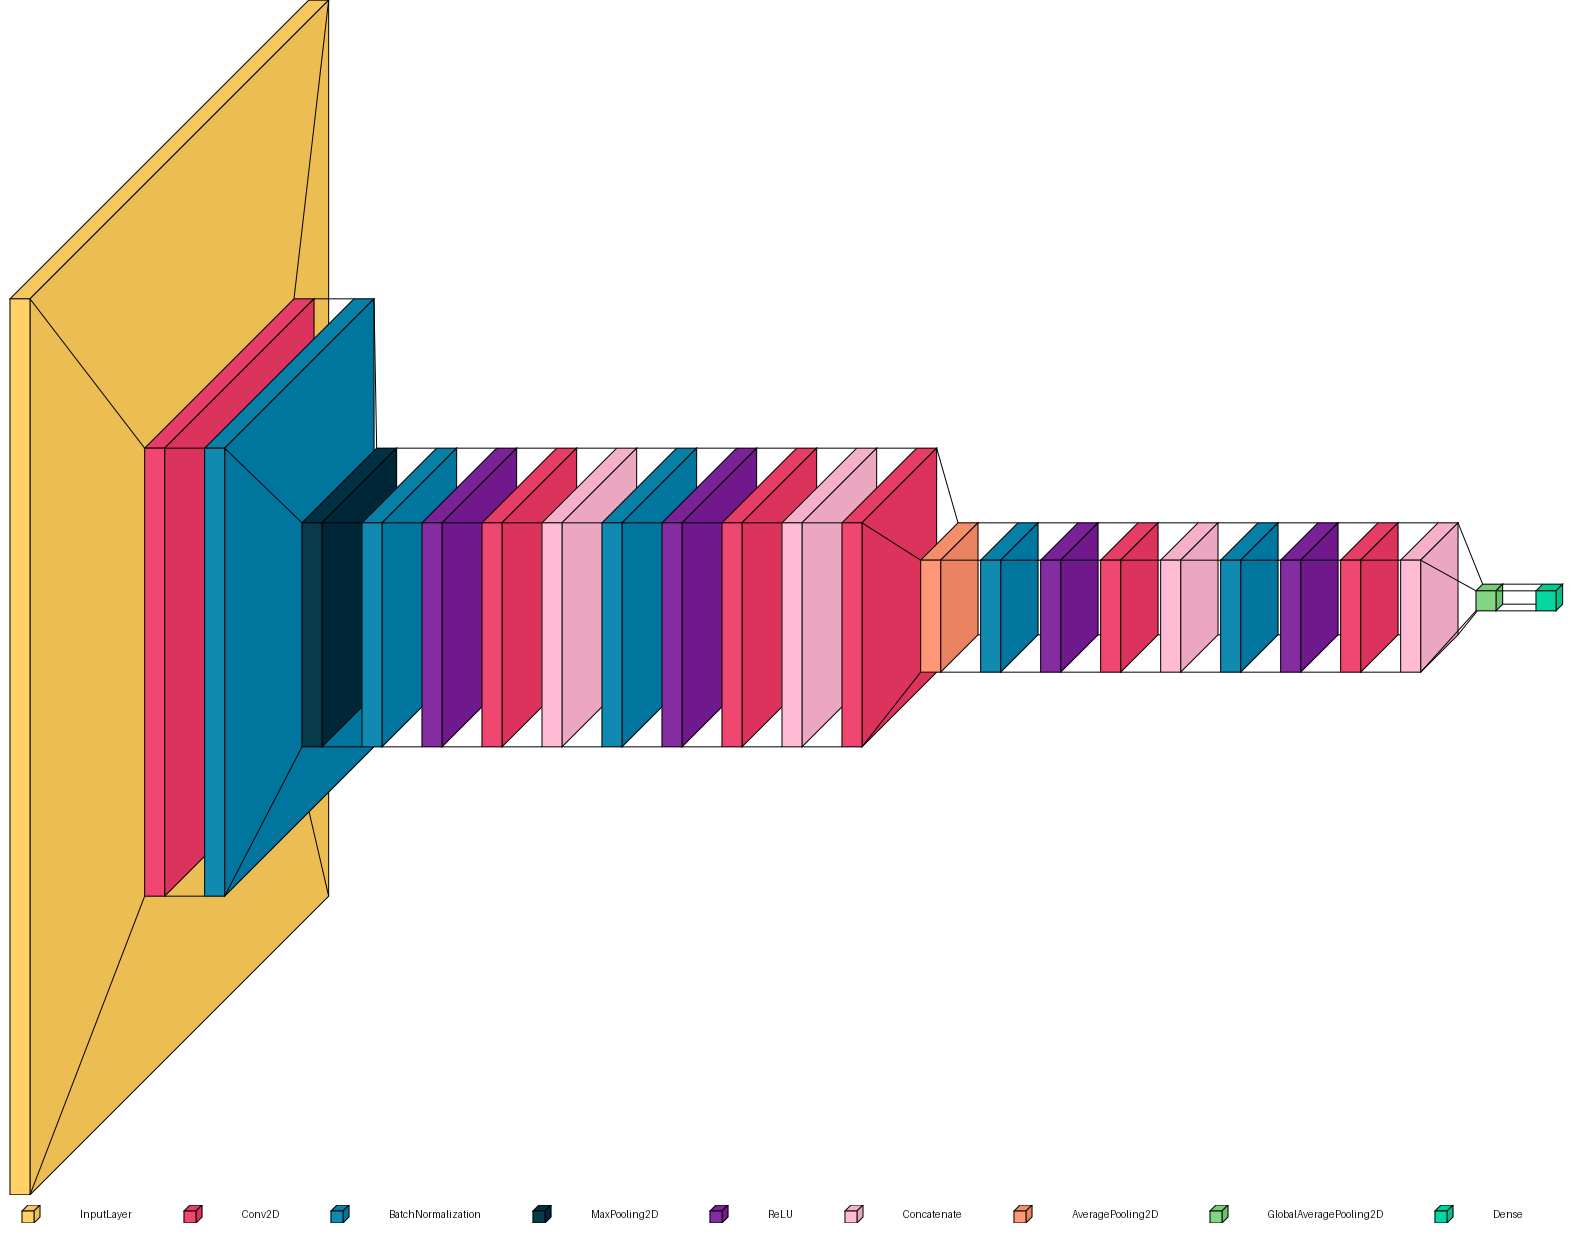

In [64]:
visualkeras.layered_view(
    baseline_model,
    legend=True,
    spacing=40, 
    draw_volume=True,  
    to_file="baseline_model_keras.png"
)


In [31]:
model_one = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
)

baseline_model.save("models/baseline_model.keras")

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.2806 - loss: 1.5756 - val_accuracy: 0.2267 - val_loss: 1.5993
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 681ms/step - accuracy: 0.4966 - loss: 1.1894 - val_accuracy: 0.2967 - val_loss: 1.8382
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.5640 - loss: 1.0072 - val_accuracy: 0.2600 - val_loss: 1.9819
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.6207 - loss: 0.8828 - val_accuracy: 0.2300 - val_loss: 2.0054
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.6464 - loss: 0.8242 - val_accuracy: 0.2583 - val_loss: 2.0866
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.6986 - loss: 0.7435 - val_accuracy: 0.2017 - val_loss: 2.7541
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.7275 - loss: 0.6933 - val_accuracy: 0.3317 - val_loss: 1.6686
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 57s 992ms/step - accuracy: 0.7437 - loss: 0.6475 - val_accuracy: 0.3383 - va

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step


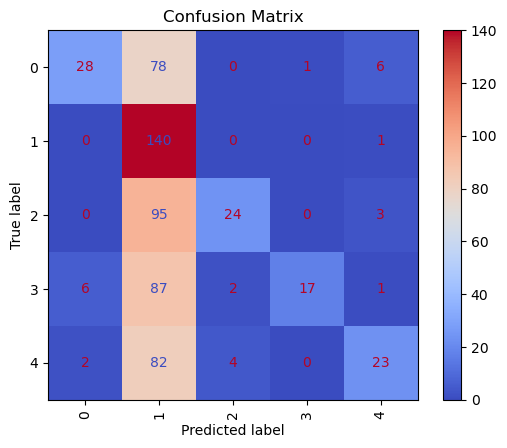

Accuracy: 0.38666666666666666


In [32]:
y_pred = baseline_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

accuracy = accuracy_score(y_test, y_pred_classes)
matrix = confusion_matrix(y_test, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(y_test))

cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

print(f"Accuracy: {accuracy}")

In [32]:
def plot_training_history(model, acc_lims=(10, 1), loss_lims=(10, 5)):
    # Plot accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.xlim(0, acc_lims[0])
    plt.ylim(0, acc_lims[1])
    plt.plot(model.history['accuracy'], label='Train Accuracy')
    plt.plot(model.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(False)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(model.history['loss'], label='Train Loss')
    plt.plot(model.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(False)
    plt.xlim(0, loss_lims[0])
    plt.ylim(0, loss_lims[1])

    
    plt.tight_layout()
    plt.show()

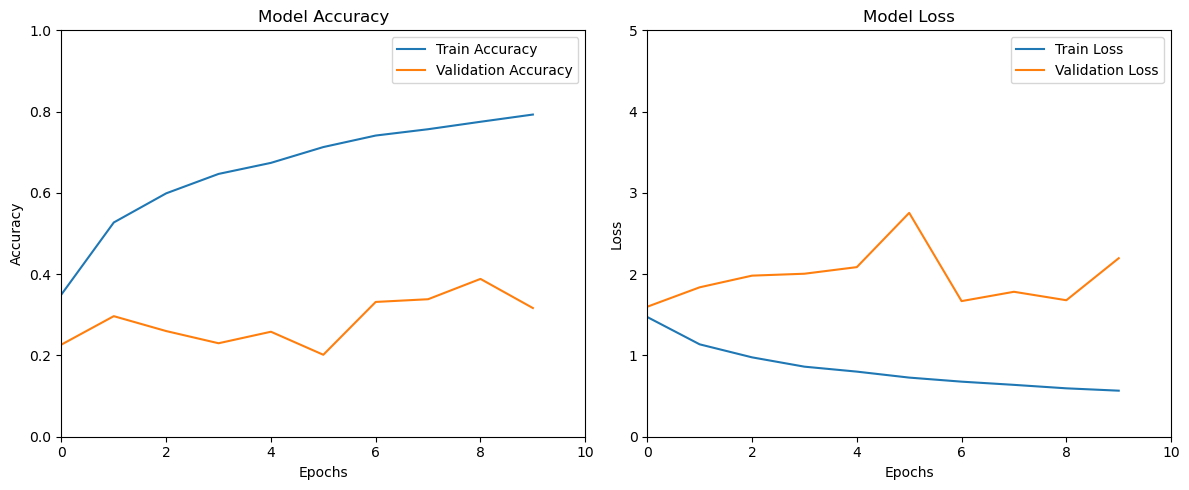

In [34]:
plot_training_history(model_one)

# Experiment 1 - He Initialisation

Using He initialisers within baseline model architecture (with seed=42 for best reproducibility)

In [35]:
def create_model_with_he_init(input_shape=(224, 224, 3), num_classes=5):
    """
    Creates a DenseNet-based model with He initialization.

    Args:
        input_shape (tuple): Shape of the input images.
        num_classes (int): Number of output classes.

    Returns:
        tf.keras.Model: Model with He initialization.
    """
    inputs = layers.Input(shape=input_shape)
    # using He initialisation
    x = layers.Conv2D(16, (7, 7), strides=2, padding="same", activation="relu",
                      kernel_initializer=initializers.HeNormal(seed=42))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding="same")(x)

    # 2 dense blocks
    for _ in range(2):  # Two layers in the block
        y = layers.BatchNormalization()(x)
        y = layers.ReLU()(y)
        y = layers.Conv2D(16, (3, 3), padding="same", kernel_initializer=initializers.HeNormal(seed=42))(y)
        # Concatenate the input with the output of the dense block
        x = layers.Concatenate()([x, y]) 

    # transition layers
    x = layers.Conv2D(32, (1, 1), activation="relu", kernel_initializer=initializers.HeNormal(seed=42))(x)
    x = layers.AveragePooling2D((2, 2))(x)

    # 2 more dense blocks
    for _ in range(2):  
        y = layers.BatchNormalization()(x)
        y = layers.ReLU()(y)
        y = layers.Conv2D(32, (3, 3), padding="same", kernel_initializer=initializers.HeNormal(seed=42))(y)
        x = layers.Concatenate()([x, y])  

    # Transition to Output
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax", kernel_initializer=initializers.HeNormal(seed=42))(x)

    model = models.Model(inputs, outputs)
    return model


In [36]:
model_with_he = create_model_with_he_init()

model_with_he.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"],
)

In [37]:
model_two = model_with_he.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
)

model_with_he.save('./models/model_with_he.keras')

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.3238 - loss: 1.5577 - val_accuracy: 0.1983 - val_loss: 4.1189
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.5291 - loss: 1.1685 - val_accuracy: 0.2083 - val_loss: 2.7389
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.6174 - loss: 0.9569 - val_accuracy: 0.3050 - val_loss: 1.8395
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 48s 848ms/step - accuracy: 0.6716 - loss: 0.8541 - val_accuracy: 0.2383 - val_loss: 2.0482
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 37s 656ms/step - accuracy: 0.6980 - loss: 0.7837 - val_accuracy: 0.2667 - val_loss: 1.8439
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 40s 708ms/step - accuracy: 0.7132 - loss: 0.7215 - val_accuracy: 0.2817 - val_loss: 1.8467
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 43s 744ms/step - accuracy: 0.7436 - loss: 0.6633 - val_accuracy: 0.4017 - val_loss: 1.4353
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 37s 651ms/step - accuracy: 0.7532 - loss: 0.6208 - val_accuracy: 0.

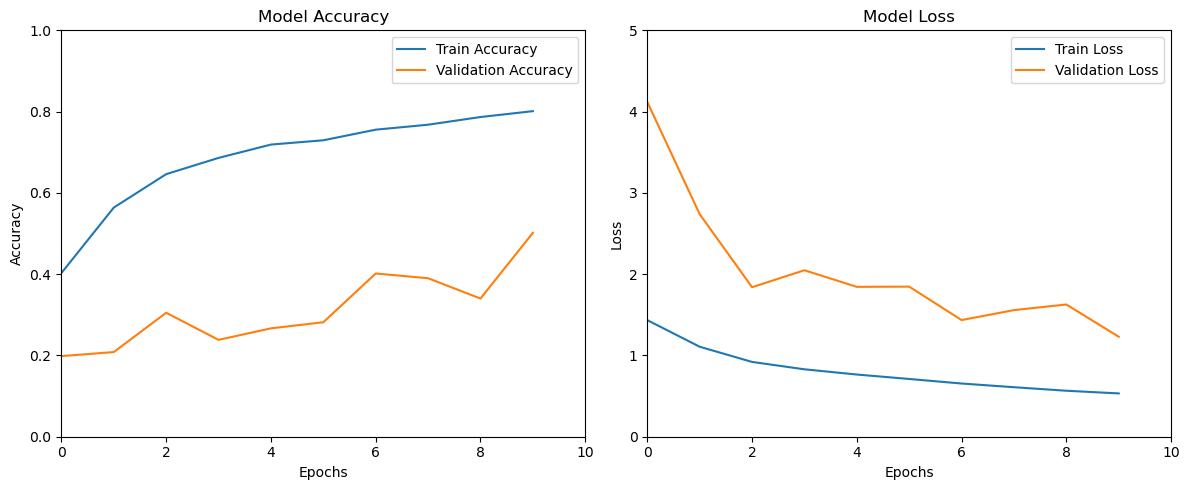

In [38]:
plot_training_history(model_two)

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 241ms/step


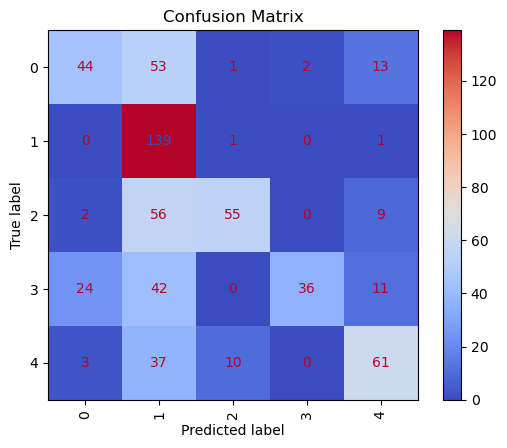

Accuracy: 0.5583333333333333


In [39]:
y_pred = model_with_he.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

accuracy = accuracy_score(y_test, y_pred_classes)
matrix = confusion_matrix(y_test, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(y_test))

cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

print(f"Accuracy: {accuracy}")

# Experiment 2 - Class Weights

Introducing Class weighs to the training

In [41]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes = np.unique(y_train),
    y = y_train,
)
weights_dict = dict(enumerate(class_weights))

print("class Weights: ", weights_dict)

class Weights:  {0: 1.0315186246418337, 1: 1.0112359550561798, 2: 1.0315186246418337, 3: 0.9782608695652174, 4: 0.9523809523809523}


In [42]:
model_two_with_weights = model_with_he.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size = 32,
    class_weight=weights_dict
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 56s 832ms/step - accuracy: 0.8081 - loss: 0.5109 - val_accuracy: 0.5300 - val_loss: 1.5096
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 72s 672ms/step - accuracy: 0.8228 - loss: 0.4820 - val_accuracy: 0.4917 - val_loss: 1.9037
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 40s 705ms/step - accuracy: 0.8358 - loss: 0.4636 - val_accuracy: 0.3650 - val_loss: 2.7705
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 47s 771ms/step - accuracy: 0.8520 - loss: 0.4256 - val_accuracy: 0.5517 - val_loss: 1.5201
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 40s 705ms/step - accuracy: 0.8624 - loss: 0.4031 - val_accuracy: 0.5800 - val_loss: 1.3967
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 38s 658ms/step - accuracy: 0.8593 - loss: 0.3913 - val_accuracy: 0.6183 - val_loss: 1.2835
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 46s 814ms/step - accuracy: 0.8788 - loss: 0.3593 - val_accuracy: 0.5817 - val_loss: 1.6959
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 42s 730ms/step - accuracy: 0.8879 - loss: 0.3302 - val_accu

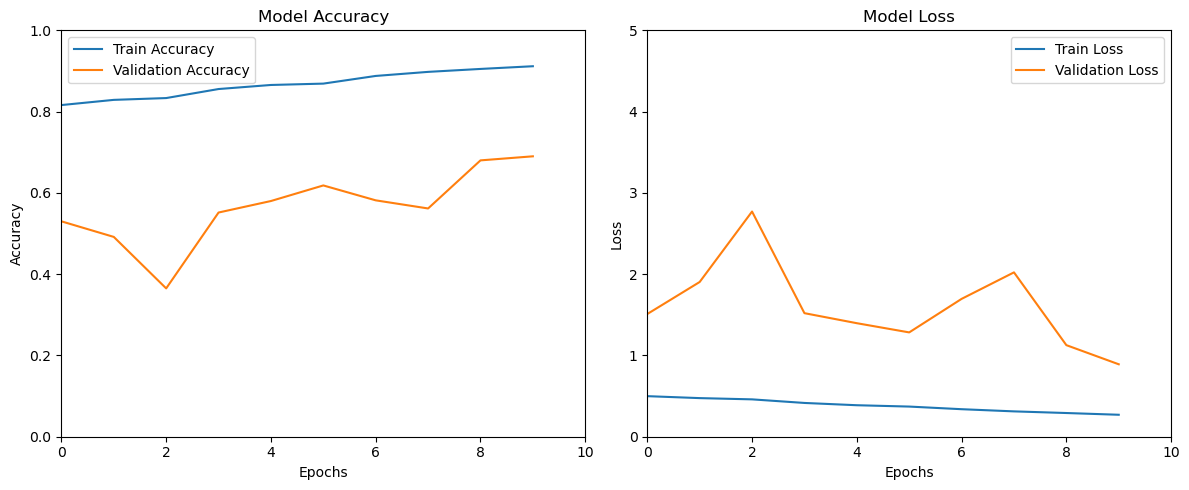

In [43]:
plot_training_history(model_two_with_weights)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step


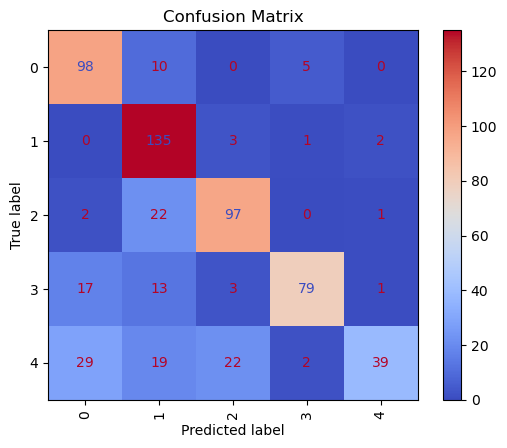

Accuracy: 0.7466666666666667


In [44]:
y_pred = model_with_he.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

accuracy = accuracy_score(y_test, y_pred_classes)
matrix = confusion_matrix(y_test, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(y_test))

cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

print(f"Accuracy: {accuracy}")

In [79]:
pd.DataFrame(model_two_with_weights.history)

,accuracy,loss,val_accuracy,val_loss
0,0.844167,0.428318,0.581667,1.944953
1,0.850833,0.398264,0.696667,0.793423
2,0.862083,0.365463,0.741667,0.685813
3,0.874583,0.328803,0.713333,0.803850
4,0.888750,0.307418,0.326667,5.579391
5,0.900417,0.270210,0.645000,1.537058
6,0.902500,0.268301,0.741667,1.015245
7,0.909167,0.252089,0.648333,1.290279
8,0.915833,0.225950,0.420000,4.509437
9,0.931250,0.201344,0.586667,1.840235


# Experiment 3 - Learning Rates

Proving 3 different learning rates to obtain the most suitable

In [45]:
def train_with_learning_rate(lr, trial_name, class_weights_dict):
    """
    Train the model with a specific learning rate.

    Args:
        lr (float): Learning rate to use.
        trial_name (str): Name of the trial for saving results.

    Returns:
        History object of the trained model.
    """
    print(f"Training with learning rate: {lr}")

    # Define optimiser with specific learning rate
    optimiser = Adam(learning_rate=lr)
    model_with_weights = create_model_with_he_init()
    model_with_weights.compile(optimizer=optimiser, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    lr_model = model_with_weights.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=32,
        class_weight=class_weights_dict 
    )

    model_with_weights.save(f"models/model_with_lr_{trial_name}.keras")

    return lr_model

In [46]:
history_high = train_with_learning_rate(0.01, "high", weights_dict)
history_medium = train_with_learning_rate(0.001, "medium", weights_dict)
history_low = train_with_learning_rate(0.0001, "low", weights_dict)

Training with learning rate: 0.01
Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 55s 773ms/step - accuracy: 0.2570 - loss: 2.3432 - val_accuracy: 0.1983 - val_loss: 7.0624
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 37s 638ms/step - accuracy: 0.4317 - loss: 1.2983 - val_accuracy: 0.1983 - val_loss: 3.9769
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 678ms/step - accuracy: 0.5364 - loss: 1.0891 - val_accuracy: 0.2467 - val_loss: 2.2430
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 659ms/step - accuracy: 0.6138 - loss: 0.9615 - val_accuracy: 0.3183 - val_loss: 3.2405
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 37s 657ms/step - accuracy: 0.6386 - loss: 0.8826 - val_accuracy: 0.2733 - val_loss: 2.8270
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 41s 722ms/step - accuracy: 0.6427 - loss: 0.8418 - val_accuracy: 0.4233 - val_loss: 1.8924
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 41s 710ms/step - accuracy: 0.6738 - loss: 0.7979 - val_accuracy: 0.3117 - val_loss: 4.0325
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 684ms/step - accuracy

In [47]:
def plot_learning_rate_trials(history_high, history_medium, history_low):
    """
    Plot training and validation accuracy/loss for different learning rates as side-by-side subplots.

    Args:
        history_high, history_medium, history_low: History objects from each trial.
    """
    # get history objects
    histories = [("High LR", history_high), ("Medium LR", history_medium), ("Low LR", history_low)]

    colors = cm.tab10(range(len(histories)))  
    fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 

    # accuracy
    for idx, (name, history) in enumerate(histories):
        axes[0].plot(history.history['val_accuracy'], label=f"Val Accuracy ({name})", color=colors[idx])
        axes[0].plot(history.history['accuracy'], label=f"Train Accuracy ({name})", linestyle="dashed", color=colors[idx])
    axes[0].set_title("Accuracy Comparison")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_xlim(0, 10)
    axes[0].legend()

    # loss
    for idx, (name, history) in enumerate(histories):
        axes[1].plot(history.history['val_loss'], label=f"Val Loss ({name})", color=colors[idx])
        axes[1].plot(history.history['loss'], label=f"Train Loss ({name})", linestyle="dashed", color=colors[idx])
    axes[1].set_title("Loss Comparison")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Loss")
    axes[1].set_xlim(0, 10)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


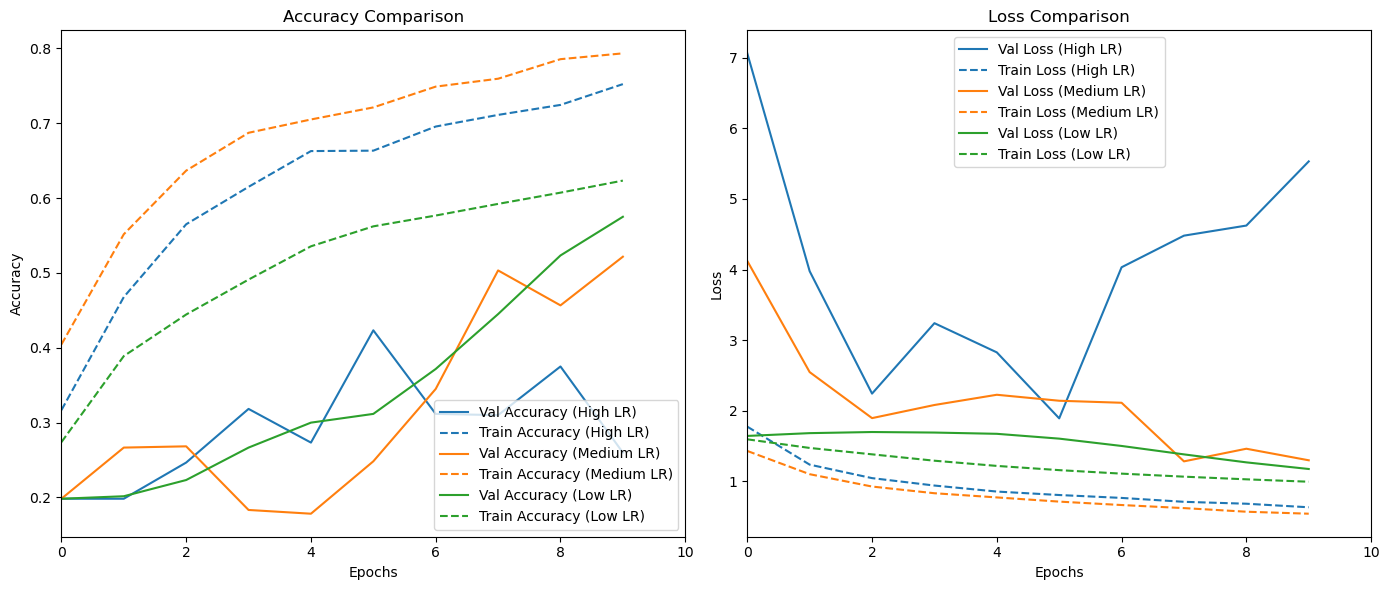

In [48]:
plot_learning_rate_trials(history_high, history_medium, history_low)

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 266ms/step


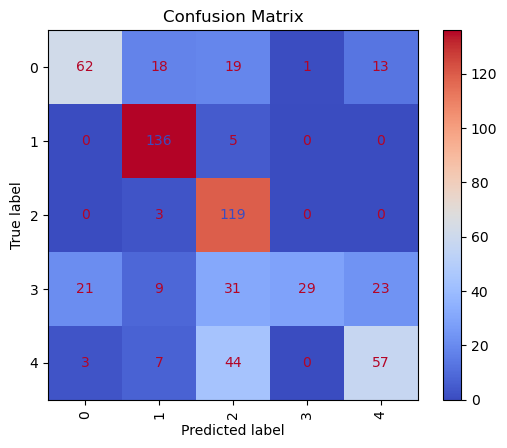

Accuracy: 0.6716666666666666


In [98]:
# get predictions of best performing lr model
model_three = models.load_model("models/model_with_lr_medium_lr.keras")

y_pred = model_three.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

accuracy = accuracy_score(y_test, y_pred_classes)
matrix = confusion_matrix(y_test, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(y_test))

cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

print(f"Accuracy: {accuracy}")

In [85]:
pd.DataFrame(data=history_high.history)

,accuracy,loss,val_accuracy,val_loss
0,0.337917,1.686201,0.188333,3.890141
1,0.443333,1.268777,0.236667,4.923334
2,0.544583,1.050452,0.216667,3.224055
3,0.617083,0.912735,0.203333,12.319494
4,0.654583,0.847416,0.380000,3.512891
5,0.675000,0.797496,0.361667,5.672387
6,0.706250,0.729137,0.318333,7.484706
7,0.726250,0.691444,0.345000,2.577840
8,0.731250,0.680778,0.541667,1.302398
9,0.740833,0.635674,0.620000,1.015768


In [86]:
pd.DataFrame(data=history_medium.history)

,accuracy,loss,val_accuracy,val_loss
0,0.426250,1.388975,0.196667,2.425707
1,0.580000,1.029328,0.301667,2.344116
2,0.656667,0.868031,0.323333,2.299012
3,0.697500,0.768918,0.281667,2.006394
4,0.733750,0.692232,0.346667,1.713690
5,0.752500,0.632767,0.568333,1.180555
6,0.771250,0.589211,0.525000,1.450364
7,0.790833,0.539516,0.633333,1.002668
8,0.807500,0.498450,0.710000,0.730771
9,0.827083,0.464378,0.770000,0.620869


In [87]:
pd.DataFrame(data=history_low.history)

,accuracy,loss,val_accuracy,val_loss
0,0.297917,1.576399,0.190000,1.695720
1,0.412500,1.436991,0.196667,1.725478
2,0.483750,1.320457,0.258333,1.676451
3,0.525417,1.219440,0.361667,1.580486
4,0.550000,1.144548,0.395000,1.447564
5,0.572917,1.086492,0.490000,1.285141
6,0.592917,1.038332,0.560000,1.155154
7,0.625417,0.996409,0.621667,1.074010
8,0.640417,0.959382,0.631667,1.011747
9,0.656667,0.926715,0.645000,0.962914


# Experiment 4 - Dropout

Addition of dropout layers to model.

In [106]:
def create_model_with_dropout(input_shape=(224, 224, 3), num_classes=5, dropout_rate=0.3):
    """
    Creates a DenseNet-based model with He initialization and dropout.

    Args:
        input_shape (tuple): Shape of the input images.
        num_classes (int): Number of output classes.

    Returns:
        tf.keras.Model: Model with He initialisation and dropout.
    """
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(16, (7, 7), strides=2, padding="same", activation="relu",
                      kernel_initializer=initializers.HeNormal(seed=42))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding="same")(x)

    # 2 dense blocks
    for _ in range(2):  
        y = layers.BatchNormalization()(x)
        y = layers.ReLU()(y)
        y = layers.Conv2D(16, (3, 3), padding="same", kernel_initializer=initializers.HeNormal(seed=42))(y)
        x = layers.Concatenate()([x, y]) 
    
    # dropout layer
    x = layers.Dropout(dropout_rate)(x)

    # transition layers
    x = layers.Conv2D(32, (1, 1), activation="relu", kernel_initializer=initializers.HeNormal(seed=42))(x)
    x = layers.AveragePooling2D((2, 2))(x)

    # 2 more dense blocks
    for _ in range(2):  
        y = layers.BatchNormalization()(x)
        y = layers.ReLU()(y)
        y = layers.Conv2D(32, (3, 3), padding="same", kernel_initializer=initializers.HeNormal(seed=42))(y)
        x = layers.Concatenate()([x, y])

    x = layers.Dropout(dropout_rate)(x)
    
    # Transition to Output
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax", kernel_initializer=initializers.HeNormal(seed=42))(x)

    model = models.Model(inputs, outputs)
    return model


In [107]:
dropout_rates = [0.1, 0.2, 0.3]
histories = {}

for rate in dropout_rates:
    print(f"Training model with dropout rate: {rate}")
    model = create_model_with_dropout(dropout_rate=rate)

    # Compile the model
    optimiser = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimiser, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    # Train the model
    rate_history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=32,
        class_weight=weights_dict
    )

    # Save history for later comparison
    histories[f"Dropout {rate}"] = rate_history

Training model with dropout rate: 0.1
Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.2537 - loss: 1.6809 - val_accuracy: 0.2000 - val_loss: 1.6363
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 41s 703ms/step - accuracy: 0.3614 - loss: 1.4963 - val_accuracy: 0.2000 - val_loss: 1.6805
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 81s 692ms/step - accuracy: 0.4331 - loss: 1.4186 - val_accuracy: 0.2233 - val_loss: 1.7098
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 674ms/step - accuracy: 0.4825 - loss: 1.3361 - val_accuracy: 0.2833 - val_loss: 1.7055
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 38s 662ms/step - accuracy: 0.5152 - loss: 1.2597 - val_accuracy: 0.3183 - val_loss: 1.6689
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 41s 727ms/step - accuracy: 0.5458 - loss: 1.1966 - val_accuracy: 0.3350 - val_loss: 1.5918
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 42s 732ms/step - accuracy: 0.5735 - loss: 1.1492 - val_accuracy: 0.3533 - val_loss: 1.4837
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 688ms/step - accurac

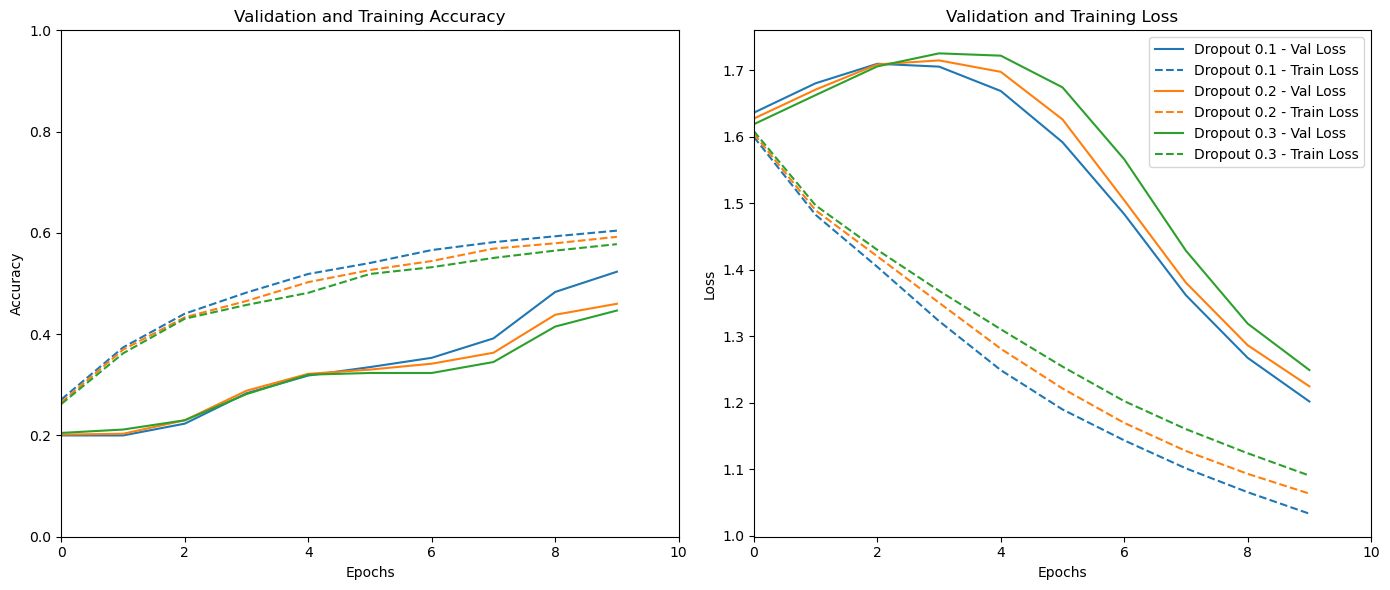

In [108]:
def plot_dropout_comparison(histories):
    """
    Plots training and validation accuracy/loss for models with different dropout rates.

    Args:
        histories (dict): Dictionary containing histories of models with different dropout rates.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = cm.tab10(range(len(histories)))

    # Plot each history
    for idx, (label, history) in enumerate(histories.items()):
        color = colors[idx]

        # Accuracy
        axes[0].plot(history.history['val_accuracy'], label=f"{label} - Val Accuracy", color=color)
        axes[0].plot(history.history['accuracy'], linestyle="dashed", label=f"{label} - Train Accuracy", color=color)
        # Loss
        axes[1].plot(history.history['val_loss'], label=f"{label} - Val Loss", color=color)
        axes[1].plot(history.history['loss'], linestyle="dashed", label=f"{label} - Train Loss", color=color)

    # accuracy
    axes[0].set_title("Validation and Training Accuracy")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Accuracy")

    axes[0].set_xlim(0, 10)
    axes[0].set_ylim(0, 1)

    # Loss 
    axes[1].set_title("Validation and Training Loss")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Loss")
    axes[1].set_xlim(0, 10)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Example usage:
plot_dropout_comparison(histories)


In [91]:
pd.DataFrame(histories['Dropout 0.1'].history)

,accuracy,loss,val_accuracy,val_loss
0,0.290000,1.580558,0.188333,1.674575
1,0.402083,1.451328,0.196667,1.729960
2,0.464583,1.350751,0.286667,1.676788
3,0.509167,1.250502,0.370000,1.574034
4,0.528333,1.175832,0.391667,1.430156
5,0.553333,1.117353,0.490000,1.258136
6,0.577917,1.070891,0.558333,1.127025
7,0.600417,1.028762,0.603333,1.049074
8,0.624583,0.991812,0.616667,0.990223
9,0.640417,0.959367,0.636667,0.946298


In [92]:
pd.DataFrame(histories['Dropout 0.2'].history)

,accuracy,loss,val_accuracy,val_loss
0,0.290833,1.585741,0.188333,1.659150
1,0.406667,1.461453,0.196667,1.725240
2,0.446667,1.377364,0.278333,1.705050
3,0.483333,1.286451,0.378333,1.598198
4,0.512500,1.208120,0.381667,1.454565
5,0.531667,1.151565,0.438333,1.285403
6,0.558333,1.103732,0.486667,1.159756
7,0.575833,1.065120,0.515000,1.097922
8,0.600417,1.025690,0.545000,1.051462
9,0.622083,0.993212,0.583333,1.002131


In [93]:
pd.DataFrame(histories['Dropout 0.3'].history)

,accuracy,loss,val_accuracy,val_loss
0,0.271667,1.591119,0.191667,1.646636
1,0.390000,1.471927,0.200000,1.725166
2,0.438333,1.395825,0.273333,1.714554
3,0.477083,1.317942,0.375000,1.619601
4,0.502500,1.247021,0.361667,1.489906
5,0.516250,1.185487,0.411667,1.326036
6,0.538333,1.135122,0.478333,1.201741
7,0.558333,1.094200,0.510000,1.117965
8,0.583333,1.055612,0.520000,1.097759
9,0.604583,1.020383,0.543333,1.069122


In [ ]:
model_four = create_model_with_dropout(dropout_rate=0.1)

# Compile the model
optimiser = Adam(learning_rate=0.0001)
model_four.compile(optimizer=optimiser, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model_four_history = model_four.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

model_four.save('models/model_four_dropout.keras')



Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 77s 813ms/step - accuracy: 0.3221 - loss: 1.5676 - val_accuracy: 0.1983 - val_loss: 3.9768
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 49s 855ms/step - accuracy: 0.5252 - loss: 1.1833 - val_accuracy: 0.2917 - val_loss: 2.3984
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 686ms/step - accuracy: 0.6093 - loss: 0.9865 - val_accuracy: 0.2900 - val_loss: 2.1069
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 38s 669ms/step - accuracy: 0.6524 - loss: 0.8768 - val_accuracy: 0.2317 - val_loss: 2.3024
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 38s 672ms/step - accuracy: 0.6886 - loss: 0.8088 - val_accuracy: 0.2317 - val_loss: 2.4320
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 676ms/step - accuracy: 0.7005 - loss: 0.7517 - val_accuracy: 0.2750 - val_loss: 2.1543
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 38s 661ms/step - accuracy: 0.7234 - loss: 0.6985 - val_accuracy: 0.1983 - val_loss: 2.7292
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 38s 662ms/step - accuracy: 0.7511 - loss: 0.6460 - val_accu

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step


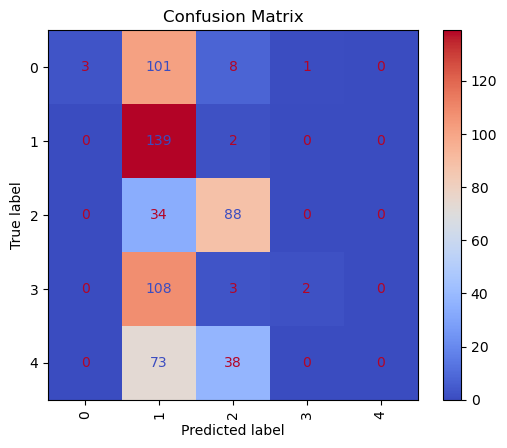

Accuracy: 0.38666666666666666


In [110]:
y_pred = model_four.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

accuracy = accuracy_score(y_test, y_pred_classes)
matrix = confusion_matrix(y_test, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(y_test))

cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

print(f"Accuracy: {accuracy}")

In [96]:
pd.DataFrame(model_four_history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.271667,1.591119,0.191667,1.646636
1,0.390000,1.471927,0.200000,1.725166
2,0.438333,1.395825,0.273333,1.714554
3,0.477083,1.317942,0.375000,1.619601
4,0.502500,1.247021,0.361667,1.489906
5,0.516250,1.185487,0.411667,1.326036
6,0.538333,1.135122,0.478333,1.201741
7,0.558333,1.094200,0.510000,1.117965
8,0.583333,1.055612,0.520000,1.097759
9,0.604583,1.020383,0.543333,1.069122


# Experiment 5 - Class Weights with unbalanced data

Relying on class weights, instead of balancing data. this keeps a lot of lost data

In [3]:
X_unbalanced, y_unbalanced = lpd('./data', balance=False)
label_encoder = LabelEncoder()
y_unbalanced = label_encoder.fit_transform(y_unbalanced)

X_train_unbalanced, X_test_unbalanced, y_train_unbalanced, y_test_unbalanced = train_test_split(
    X_unbalanced, y_unbalanced, 
    test_size=0.2, 
    random_state=42
)

X_train_unbalanced, X_val_unbalanced, y_train_unbalanced, y_val_unbalanced = train_test_split(
    X_train_unbalanced, y_train_unbalanced, 
    test_size=0.25, 
    random_state=42
)


resized file count (hatchback) : 602
resized file count (moped) : 600
resized file count (pickup) : 1689
resized file count (seden) : 1222
resized file count (suv) : 680
augmented file count (hatchback) : 602
augmented file count (moped) : 600
augmented file count (pickup) : 1689
augmented file count (seden) : 1222
augmented file count (suv) : 680
Deleted processed_data


In [101]:
class_weights_unbalanced = compute_class_weight(
    class_weight='balanced',
    classes = np.unique(y_train_unbalanced),
    y = y_train_unbalanced,
)
weights_dict_unbalanced = dict(enumerate(class_weights_unbalanced))

print("class Weights: ", weights_dict_unbalanced)

class Weights:  {0: 1.5753424657534247, 1: 1.6715116279069768, 2: 0.5534167468719923, 3: 0.8008356545961003, 4: 1.4058679706601467}


In [102]:
model_five = create_model_with_dropout(dropout_rate=0.1)

# Compile the model
optimiser = Adam(learning_rate=0.0001)
model_five.compile(optimizer=optimiser, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model_five_history = model_five.fit(
    X_train_unbalanced, y_train_unbalanced,
    validation_data=(X_val_unbalanced, y_val_unbalanced),
    epochs=10,
    batch_size=32,
    class_weight=weights_dict_unbalanced
)

model_five.save('models/model_five_unbalaned.keras')

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.2496 - loss: 1.6491 - val_accuracy: 0.2628 - val_loss: 1.5941
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 98s 784ms/step - accuracy: 0.4136 - loss: 1.4631 - val_accuracy: 0.2701 - val_loss: 1.7500
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 67s 747ms/step - accuracy: 0.5188 - loss: 1.3608 - val_accuracy: 0.3212 - val_loss: 1.7576
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 64s 705ms/step - accuracy: 0.5617 - loss: 1.2589 - val_accuracy: 0.3243 - val_loss: 1.5882
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 76s 837ms/step - accuracy: 0.5887 - loss: 1.1653 - val_accuracy: 0.4567 - val_loss: 1.3362
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 63s 701ms/step - accuracy: 0.6192 - loss: 1.0932 - val_accuracy: 0.5912 - val_loss: 1.1492
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 67s 739ms/step - accuracy: 0.6400 - loss: 1.0376 - val_accuracy: 0.6350 - val_loss: 1.0555
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 66s 725ms/step - accuracy: 0.6633 - loss: 0.9910 - val_accura

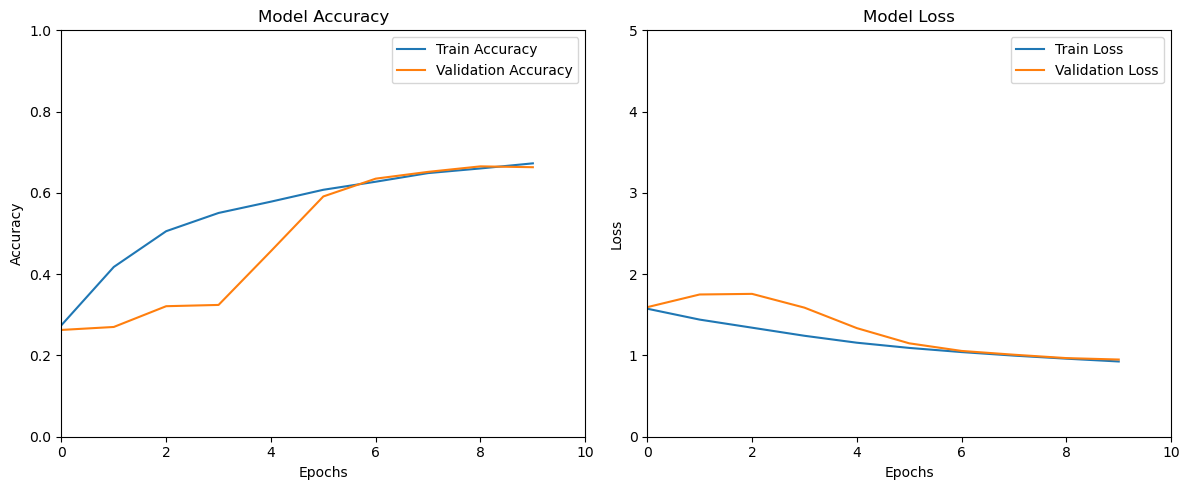

In [103]:
plot_training_history(model_five_history)

In [104]:
pd.DataFrame(model_five_history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.274435,1.575011,0.262774,1.594112
1,0.417739,1.440923,0.270073,1.750049
2,0.505739,1.341518,0.321168,1.757578
3,0.550609,1.242049,0.324296,1.588150
4,0.578435,1.156733,0.456726,1.336191
5,0.607652,1.092610,0.591241,1.149214
6,0.627478,1.041511,0.635036,1.055478
7,0.648696,0.997849,0.651721,1.008857
8,0.660174,0.960245,0.665276,0.967381
9,0.672696,0.925678,0.663191,0.949626


30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 268ms/step


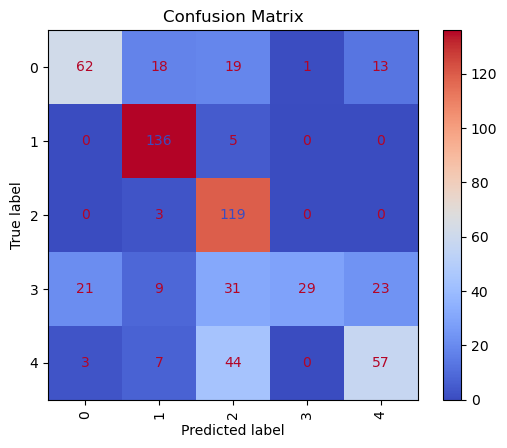

Accuracy: 0.64859228362878


In [105]:
y_pred = model_five.predict(X_test_unbalanced)
y_pred_classes = np.argmax(y_pred, axis=1)

accuracy = accuracy_score(y_test_unbalanced, y_pred_classes)
cm_matrix = confusion_matrix(y_test_unbalanced, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(y_test_unbalanced))

cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

print(f"Accuracy: {accuracy}")

# Experiment 6 - Categorical Focal Crossentropy

Changing the loss to categorical focal crossentropy

In [29]:
y_train_one_hot = to_categorical(y_train_unbalanced, num_classes=5)
y_val_one_hot = to_categorical(y_val_unbalanced, num_classes=5)

In [61]:
model_six = create_model_with_dropout(dropout_rate=0.1)

optimiser = Adam(learning_rate=0.0001)
model_six.compile(
    optimizer=optimiser, 
    loss="categorical_focal_crossentropy", 
    metrics=["accuracy"],  
)

history_focal_loss = model_six.fit(
    X_train_unbalanced, y_train_one_hot,
    validation_data=(X_val_unbalanced, y_val_one_hot),
    epochs=10,
    batch_size=32,
    class_weight=weights_dict_unbalanced
)

model_six.save('models/model_six_focal_loss.keras')

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 125s 948ms/step - accuracy: 0.2470 - loss: 0.2723 - val_accuracy: 0.2628 - val_loss: 0.2589
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 79s 862ms/step - accuracy: 0.4103 - loss: 0.2196 - val_accuracy: 0.2753 - val_loss: 0.3040
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 73s 806ms/step - accuracy: 0.4953 - loss: 0.1983 - val_accuracy: 0.3097 - val_loss: 0.3057
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 76s 837ms/step - accuracy: 0.5380 - loss: 0.1812 - val_accuracy: 0.3264 - val_loss: 0.2590
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 70s 710ms/step - accuracy: 0.5686 - loss: 0.1673 - val_accuracy: 0.4734 - val_loss: 0.1956
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 74s 824ms/step - accuracy: 0.5964 - loss: 0.1548 - val_accuracy: 0.6058 - val_loss: 0.1576
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 66s 730ms/step - accuracy: 0.6243 - loss: 0.1447 - val_accuracy: 0.6413 - val_loss: 0.1434
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 70s 768ms/step - accuracy: 0.6390 - loss: 0.1355 - val_acc

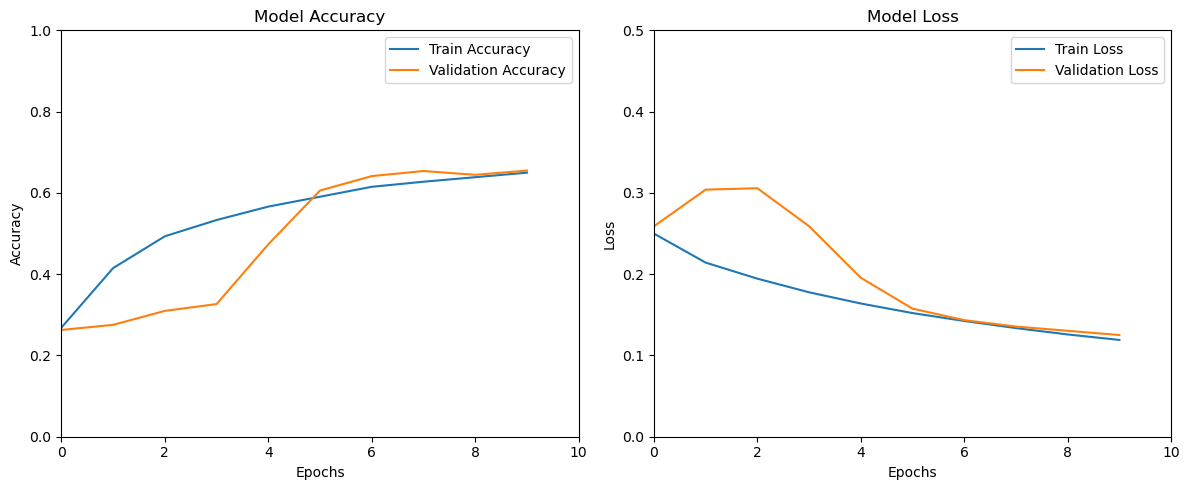

In [62]:
plot_training_history(history_focal_loss, loss_lims=(10, 0.5))

30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step


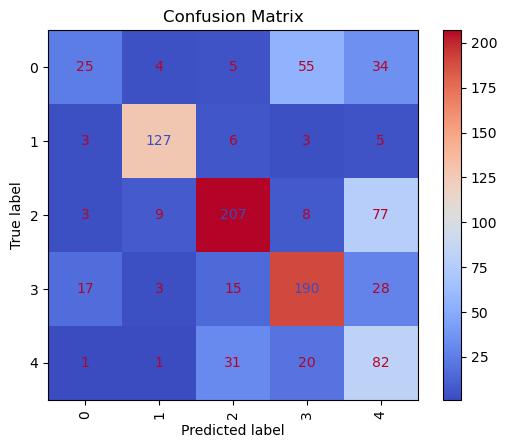

Accuracy: 0.6579770594369134


In [65]:
# Moving to one-hot encoding for evaluation (focal crossentropy requires one-hot encoded labels)
y_test_one_hot = to_categorical(y_test_unbalanced, num_classes=5)

y_test_classes = np.argmax(y_test_one_hot, axis=1)
y_pred = model_six.predict(X_test_unbalanced)
y_pred_classes = np.argmax(y_pred, axis=1)

accuracy = accuracy_score(y_test_classes, y_pred_classes)
matrix = confusion_matrix(y_test_classes, y_pred_classes)

# Display confusion matrix
cm_d = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(y_test_classes))
cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

print(f"Accuracy: {accuracy}")

In [66]:
pd.DataFrame(history_focal_loss.history)

,accuracy,loss,val_accuracy,val_loss
0,0.268522,0.249938,0.262774,0.258885
1,0.414957,0.214243,0.275287,0.303999
2,0.493217,0.194478,0.309698,0.305725
3,0.533217,0.177701,0.326382,0.259043
4,0.566261,0.163901,0.473410,0.195554
5,0.590609,0.152139,0.605839,0.157582
6,0.614956,0.142395,0.641293,0.143423
7,0.627478,0.133654,0.653806,0.135556
8,0.638609,0.125821,0.644421,0.130330
9,0.649739,0.119092,0.654849,0.125110


# Experiment 7 - Oversampling

using a random over sampler to help the model generalise for minority classes. With no class weights.

In [27]:
X_train_flat = X_train_unbalanced.reshape(X_train_unbalanced.shape[0], -1)
ros = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = ros.fit_resample(X_train_flat, y_train_unbalanced)
X_train_resampled = X_train_resampled.reshape(
    -1,
    X_train_unbalanced.shape[1],
    X_train_unbalanced.shape[2],
    X_train_unbalanced.shape[3]
)

y_train_resampled_one_hot = to_categorical(y_train_resampled, num_classes=5)

In [69]:
model_seven = create_model_with_dropout(dropout_rate=0.1)

model_seven.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss="categorical_focal_crossentropy", 
    metrics=["accuracy"],  
)

history_oversampling = model_seven.fit(
    X_train_resampled, y_train_resampled_one_hot,
    validation_data=(X_val_unbalanced, y_val_one_hot),
    epochs=10,
    batch_size=32
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 180s 963ms/step - accuracy: 0.2841 - loss: 0.2578 - val_accuracy: 0.2701 - val_loss: 0.2918
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 138s 838ms/step - accuracy: 0.4596 - loss: 0.1953 - val_accuracy: 0.3201 - val_loss: 0.2776
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 137s 837ms/step - accuracy: 0.5529 - loss: 0.1635 - val_accuracy: 0.4901 - val_loss: 0.1850
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 792ms/step - accuracy: 0.6072 - loss: 0.1415 - val_accuracy: 0.6319 - val_loss: 0.1421
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 124s 759ms/step - accuracy: 0.6358 - loss: 0.1271 - val_accuracy: 0.6465 - val_loss: 0.1289
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 814ms/step - accuracy: 0.6641 - loss: 0.1161 - val_accuracy: 0.6601 - val_loss: 0.1207
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 786ms/step - accuracy: 0.6802 - loss: 0.1076 - val_accuracy: 0.6820 - val_loss: 0.1153
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 714ms/step - accuracy: 0.6949 -

In [70]:
model_seven.save("models/model_seven_oversampled.keras")

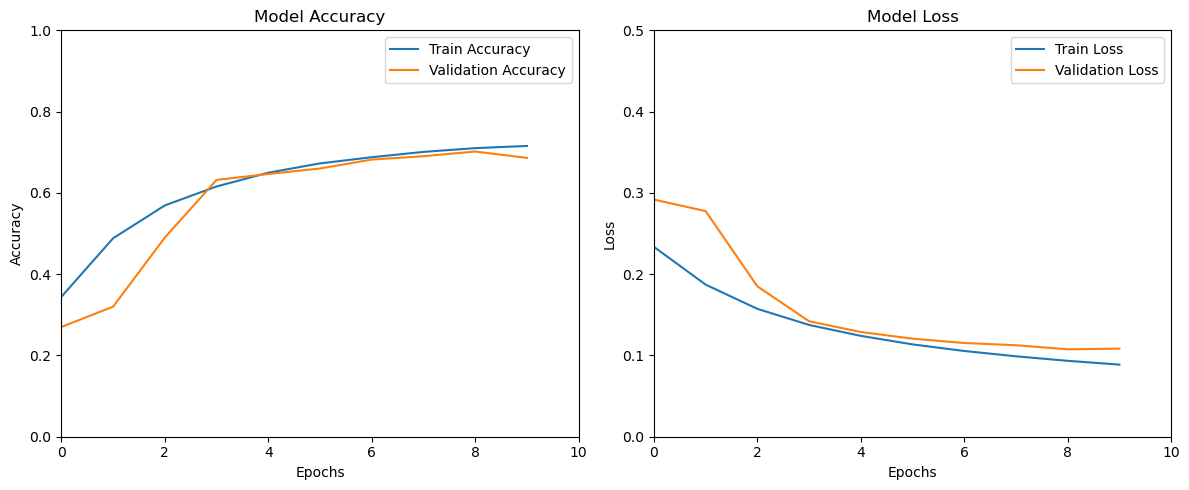

In [71]:
plot_training_history(history_oversampling, loss_lims=(10, 0.5))

30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step


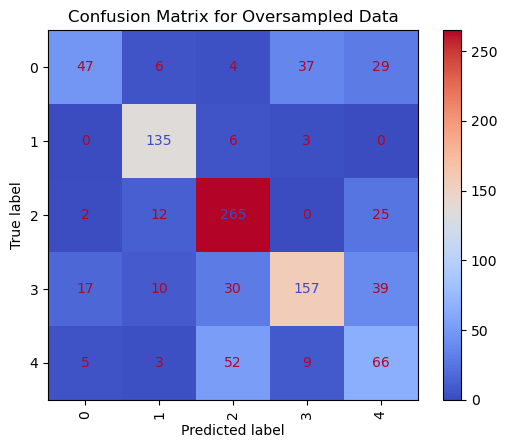

Accuracy: 0.6986444212721585


In [72]:
y_pred_probs = model_seven.predict(X_test_unbalanced)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_test_classes = np.argmax(y_test_one_hot, axis=1)

accuracy = accuracy_score(y_test_classes, y_pred_classes)
matrix = confusion_matrix(y_test_classes, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(y_test_classes))
cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix for Oversampled Data")
plt.show()

print(f"Accuracy: {accuracy}")

In [73]:
pd.DataFrame(history_oversampling.history)

,accuracy,loss,val_accuracy,val_loss
0,0.344370,0.233630,0.270073,0.291772
1,0.488354,0.187143,0.320125,0.277616
2,0.569201,0.157326,0.490094,0.185021
3,0.615784,0.137539,0.631908,0.142081
4,0.649663,0.124094,0.646507,0.128853
5,0.672570,0.113620,0.660063,0.120660
6,0.687777,0.105500,0.681960,0.115305
7,0.700866,0.098945,0.690302,0.112556
8,0.710106,0.093380,0.701773,0.107545
9,0.715496,0.088715,0.686131,0.108363


In [74]:
model_seven.save("models/model_seven_oversampling.keras")

# Experiment 8 - Regularisation Layers

Editing the previous model (addition of dropout) to include L2 regularisation. Aiming to reduce misclassifications of minority classes, and forcing the model to generalise more.

In [75]:
def create_model_with_regularisation(
        input_shape=(224, 224, 3), 
        num_classes=5, 
        dropout_rate=0.2, 
        l2_factor=0.01
    ):
    """
    Creates a DenseNet-based model with He Init., Dropout, and L2 Regularisation

    Args:
        input_shape (tuple): Shape of the input images.
        num_classes (int): Number of output classes.
        dropout_rate (float): Dropout rate to apply between layers.
        l2_factor (float): L2 regularisation strength.

    Returns:
        tf.keras.Model: Model with He initialisation and dropout.
    """
    inputs = layers.Input(shape=input_shape)

    #  convolution now with l2 regularisation
    x = layers.Conv2D(
        16, (7, 7), 
        strides=2, padding="same", 
        activation="relu",
        kernel_initializer=initializers.HeNormal(seed=42),
        kernel_regularizer=regularizers.l2(l2_factor)        
    )(inputs)

    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding="same")(x)

    # 2 dense blocks
    for _ in range(2): 
        y = layers.BatchNormalization()(x)
        y = layers.ReLU()(y)
        y = layers.Conv2D(
            16, (3, 3), 
            padding="same", 
            kernel_initializer=initializers.HeNormal(seed=42),
            kernel_regularizer=regularizers.l2(l2_factor)    
        )(y)
        x = layers.Concatenate()([x, y]) 
    
    # dropout layer
    x = layers.Dropout(dropout_rate)(x)

    # transition layers
    x = layers.Conv2D(
        32, (1, 1), 
        activation="relu", 
        kernel_initializer=initializers.HeNormal(seed=42),
        kernel_regularizer=regularizers.l2(l2_factor)
    )(x)
    x = layers.AveragePooling2D((2, 2))(x)

    # 2 more dense blocks
    for _ in range(2): 
        y = layers.BatchNormalization()(x)
        y = layers.ReLU()(y)
        y = layers.Conv2D(
            32, (3, 3), 
            padding="same", 
            kernel_initializer=initializers.HeNormal(seed=42),
            kernel_regularizer=regularizers.l2(l2_factor)
        )(y)
        x = layers.Concatenate()([x, y])

    x = layers.Dropout(dropout_rate)(x)
    
    # Transition to Output
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(
        num_classes, 
        activation="softmax", 
        kernel_initializer=initializers.HeNormal(seed=42)
    )(x)

    model = models.Model(inputs, outputs)
    return model


In [76]:
l2_options = [0.02, 0.01, 0.005]
l2_histories = {}
l2_accuracies = {}
for l2 in l2_options:
    model_eight = create_model_with_regularisation(dropout_rate=0.1, l2_factor=l2)

    model_eight.compile(
        optimizer=Adam(learning_rate=0.0001), 
        loss="categorical_focal_crossentropy", 
        metrics=["accuracy"],  
    )

    history_l2 = model_eight.fit(
        X_train_resampled, y_train_resampled_one_hot,
        validation_data=(X_val_unbalanced, y_val_one_hot),
        epochs=10,
        batch_size=32
    )

    model_eight.save(f"models/model_eight_l2_{l2}.keras")
    y_pred_probs = model_eight.predict(X_test_unbalanced)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    y_test_classes = np.argmax(y_test_one_hot, axis=1)

    accuracy = accuracy_score(y_test_classes, y_pred_classes)

    l2_accuracies[str(l2)] = accuracy
    l2_histories[str(l2)] = history_l2.history




Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.2426 - loss: 5.8050 - val_accuracy: 0.2784 - val_loss: 4.9382
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 132s 810ms/step - accuracy: 0.3947 - loss: 4.6465 - val_accuracy: 0.2513 - val_loss: 4.0017
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 790ms/step - accuracy: 0.4692 - loss: 3.7292 - val_accuracy: 0.2492 - val_loss: 3.2290
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 799ms/step - accuracy: 0.5328 - loss: 3.0034 - val_accuracy: 0.3577 - val_loss: 2.6145
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 129s 793ms/step - accuracy: 0.5835 - loss: 2.4323 - val_accuracy: 0.4672 - val_loss: 2.1327
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 129s 781ms/step - accuracy: 0.6112 - loss: 1.9836 - val_accuracy: 0.4880 - val_loss: 1.7611
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 136s 830ms/step - accuracy: 0.6438 - loss: 1.6299 - val_accuracy: 0.5266 - val_loss: 1.4623
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 127s 780ms/step - accuracy: 0.6613 - lo

In [77]:
def plot_l2_comparison(histories):
    """
    Plots training and validation accuracy/loss for models with different dropout rates.

    Args:
        histories (dict): Dictionary containing histories of models with different dropout rates.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = cm.tab10(range(len(histories)))

    # Plot each history
    for idx, (label, history) in enumerate(histories.items()):
        color = colors[idx]
        # Accuracy
        axes[0].plot(history['val_accuracy'], label=f"{label} - Val Accuracy", color=color)
        axes[0].plot(history['accuracy'], linestyle="dashed", label=f"{label} - Train Accuracy", color=color)

        # Loss
        axes[1].plot(history['val_loss'], label=f"{label} - Val Loss", color=color)
        axes[1].plot(history['loss'], linestyle="dashed", label=f"{label} - Train Loss", color=color)

    # Accuracy
    axes[0].set_title("Validation and Training Accuracy")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_xlim(0, 10)
    axes[0].set_ylim(0, 1)

    # Loss
    axes[1].set_title("Validation and Training Loss")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Loss")
    axes[1].set_xlim(0, 10)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    

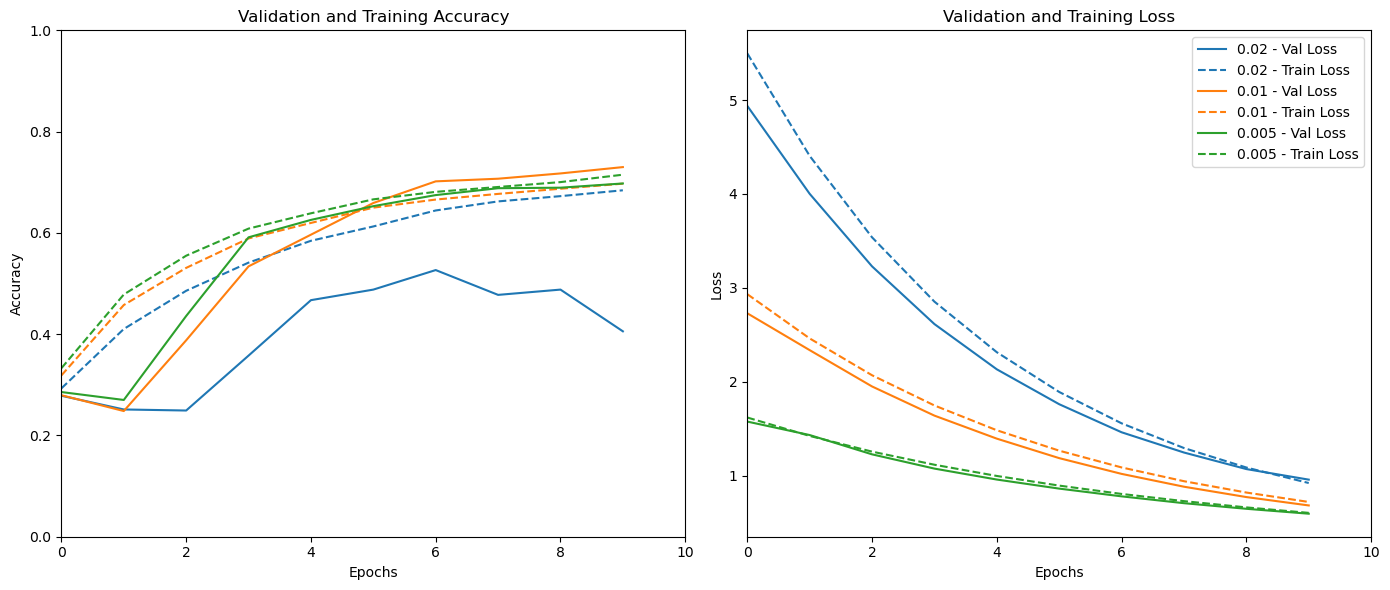

In [78]:
plot_l2_comparison(l2_histories)

30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step


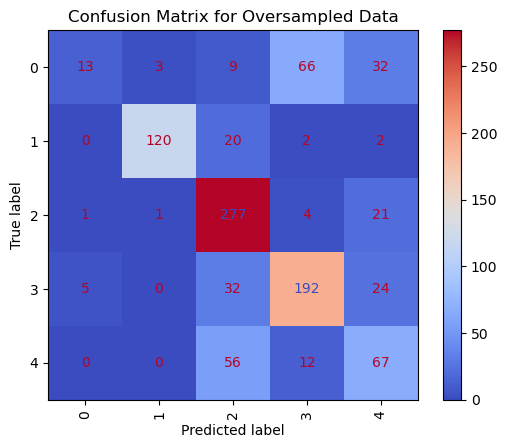

Accuracy: 0.6976016684045881


In [115]:
model_eight = models.load_model("models/model_eight_l2_0.005.keras")

y_pred_probs = model_eight.predict(X_test_unbalanced)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_test_classes = np.argmax(y_test_one_hot, axis=1)

accuracy = accuracy_score(y_test_classes, y_pred_classes)
matrix = confusion_matrix(y_test_classes, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(y_test_classes))
cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix for Oversampled Data")
plt.show()

print(f"Accuracy: {accuracy}")

# Experiment 9 - Attention Layers
Adding attention layers based on 'Attention is all you need' Vaswani, A. 2017.

In [80]:
def attention_layer(x):
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(x.shape[-1] // 16, activation='relu')(se)
    se = layers.Dense(x.shape[-1], activation='sigmoid')(se)

    se = layers.Reshape((1, 1, x.shape[-1]))(se)
    x = layers.Multiply()([x, se])

    return x

In [81]:
def create_model_with_attention(
        input_shape=(224, 224, 3), 
        num_classes=5, 
        dropout_rate=0.2, 
        l2_factor=0.01
    ):
    """
    Creates a DenseNet-based model with He Init., Dropout, and L2 Regularisation

    Args:
        input_shape (tuple): Shape of the input images.
        num_classes (int): Number of output classes.
        dropout_rate (float): Dropout rate to apply between layers.
        l2_factor (float): L2 regularisation strength.

    Returns:
        tf.keras.Model: Model with He initialisation and dropout.
    """
    inputs = layers.Input(shape=input_shape)

    # Initial convolution now with l2 regularisation
    x = layers.Conv2D(
        16, (7, 7), 
        strides=2, padding="same", 
        activation="relu",
        kernel_initializer=initializers.HeNormal(seed=42),
        kernel_regularizer=regularizers.l2(l2_factor)        
    )(inputs)

    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding="same")(x)

    # 2 dense blocks
    for _ in range(2): 
        y = layers.BatchNormalization()(x)
        y = layers.ReLU()(y)
        y = layers.Conv2D(
            16, (3, 3), 
            padding="same", 
            kernel_initializer=initializers.HeNormal(seed=42),
            kernel_regularizer=regularizers.l2(l2_factor)    
        )(y)
        x = layers.Concatenate()([x, y]) 
    
    x = attention_layer(x)
    x = layers.Dropout(dropout_rate)(x)

    # transition layers
    x = layers.Conv2D(
        32, (1, 1), 
        activation="relu", 
        kernel_initializer=initializers.HeNormal(seed=42),
        kernel_regularizer=regularizers.l2(l2_factor)
    )(x)
    x = layers.AveragePooling2D((2, 2))(x)

    # 2 more dense blocks
    for _ in range(2): 
        y = layers.BatchNormalization()(x)
        y = layers.ReLU()(y)
        y = layers.Conv2D(
            32, (3, 3), 
            padding="same", 
            kernel_initializer=initializers.HeNormal(seed=42),
            kernel_regularizer=regularizers.l2(l2_factor)
        )(y)
        x = layers.Concatenate()([x, y])

    x = layers.Dropout(dropout_rate)(x)
    
    # Transition to Output
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(
        num_classes, 
        activation="softmax", 
        kernel_initializer=initializers.HeNormal(seed=42)
    )(x)

    model = models.Model(inputs, outputs)
    return model


In [82]:
model_nine = create_model_with_attention()


model_nine.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss="categorical_focal_crossentropy", 
    metrics=["accuracy"],  
)

history_attention = model_nine.fit(
    X_train_resampled, y_train_resampled_one_hot,
    validation_data=(X_val_unbalanced, y_val_one_hot),
    epochs=10,
    batch_size=32,
    class_weight=weights_dict_unbalanced
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 210s 889ms/step - accuracy: 0.2510 - loss: 3.1244 - val_accuracy: 0.2117 - val_loss: 2.7735
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 136s 812ms/step - accuracy: 0.3735 - loss: 2.6174 - val_accuracy: 0.1481 - val_loss: 2.4209
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 790ms/step - accuracy: 0.4505 - loss: 2.2127 - val_accuracy: 0.2200 - val_loss: 2.0646
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 125s 764ms/step - accuracy: 0.4935 - loss: 1.8809 - val_accuracy: 0.2763 - val_loss: 1.7496
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 132s 794ms/step - accuracy: 0.5238 - loss: 1.6066 - val_accuracy: 0.3358 - val_loss: 1.4940
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 128s 783ms/step - accuracy: 0.5450 - loss: 1.3781 - val_accuracy: 0.3775 - val_loss: 1.2879
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 127s 772ms/step - accuracy: 0.5752 - loss: 1.1884 - val_accuracy: 0.4369 - val_loss: 1.1232
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 125s 754ms/step - accuracy: 0.5977 -

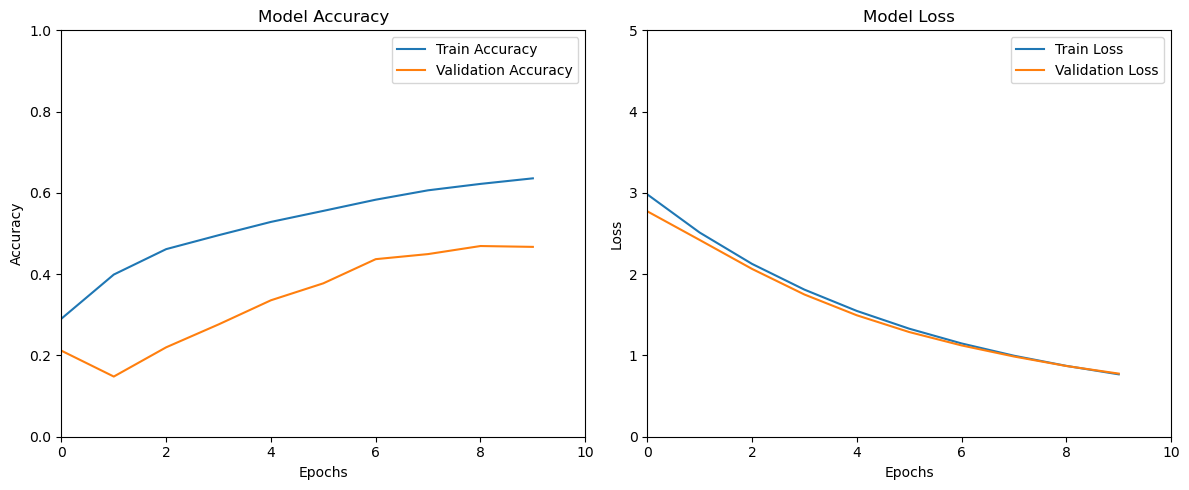

In [83]:
plot_training_history(history_attention)

In [ ]:
pd.DataFrame(history_attention.history)

,accuracy,loss,val_accuracy,val_loss
0,0.278700,2.816505,0.183525,2.458966
1,0.379639,2.125398,0.180396,1.925709
2,0.453863,1.626745,0.263816,1.499831
3,0.491408,1.266770,0.340980,1.177212
4,0.518700,1.005018,0.401460,0.932279
5,0.557256,0.812669,0.495308,0.755770
6,0.584404,0.670971,0.541189,0.627138
7,0.611264,0.565682,0.587070,0.529239
8,0.626426,0.486801,0.612096,0.457419
9,0.638267,0.426941,0.622523,0.403816


30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step


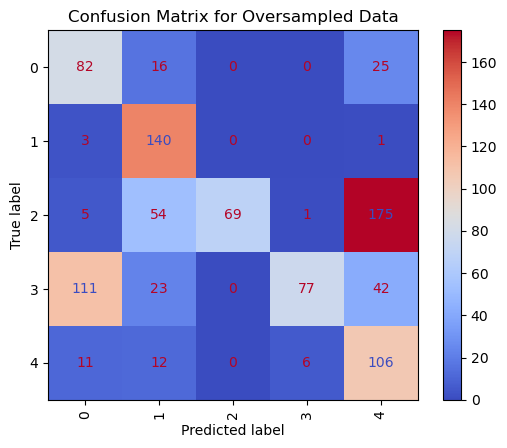

Accuracy: 0.4942648592283629


In [84]:
y_pred_probs = model_nine.predict(X_test_unbalanced)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_test_classes = np.argmax(y_test_one_hot, axis=1)

accuracy = accuracy_score(y_test_classes, y_pred_classes)
matrix = confusion_matrix(y_test_classes, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(y_test_classes))
cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix for Oversampled Data")
plt.show()

print(f"Accuracy: {accuracy}")

# Experiment 10 - Hyperparameter Tuning

Tuning the dropout rates, l2 factors, and learning rates to find the best model.

In [85]:
def build_model(hp):
    dropout_rate = hp.Choice('dropout_rate', values=[0.05, 0.1, 0.075])
    l2_factor = hp.Choice('l2_factor', values=[0.01, 0.005, 0.0001])
    learning_rate = hp.Choice('learning_rate', values=[0.0001, 0.0005, 0.00075])

    model = create_model_with_regularisation(dropout_rate=dropout_rate, l2_factor=l2_factor)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate), 
        loss="categorical_focal_crossentropy", 
        metrics=["accuracy"],  
    )
    return model

In [87]:
# Using hyperband tuner, as a more efficient search algorithm
# STILL TAKES A LONG TIME TO RUN

tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=10,
)

tuner.search(
    X_train_resampled, y_train_resampled_one_hot,
    validation_data=(X_val_unbalanced, y_val_one_hot),
    epochs=10,
    batch_size=32
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)
best_model.save("models/best_model.keras")

print(f"Best Hyperparameters: {best_hps}")

Trial 30 Complete [00h 19m 31s]
val_accuracy: 0.7278414964675903

Best val_accuracy So Far: 0.7685088515281677
Total elapsed time: 04h 34m 49s
Best Hyperparameters: <keras_tuner.src.engine.hyperparameters.hyperparameters.HyperParameters object at 0x1915ee5d0>


/opt/anaconda3/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 50 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 138s 740ms/step - accuracy: 0.4038 - loss: 0.2390 - val_accuracy: 0.1262 - val_loss: 0.6562
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 674ms/step - accuracy: 0.6569 - loss: 0.1445 - val_accuracy: 0.3952 - val_loss: 0.2759
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 644ms/step - accuracy: 0.7099 - loss: 0.1179 - val_accuracy: 0.6319 - val_loss: 0.1493
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 654ms/step - accuracy: 0.7586 - loss: 0.1023 - val_accuracy: 0.7570 - val_loss: 0.1080
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 659ms/step - accuracy: 0.7864 - loss: 0.0900 - val_accuracy: 0.6048 - val_loss: 0.2132
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 642ms/step - accuracy: 0.8079 - loss: 0.0824 - val_accuracy: 0.6163 - val_loss: 0.1786
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 645ms/step - accuracy: 0.8378 - loss: 0.0746 - val_accuracy: 0.6924 - val_loss: 0.1447
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 646ms/step - accuracy: 0.8516 -

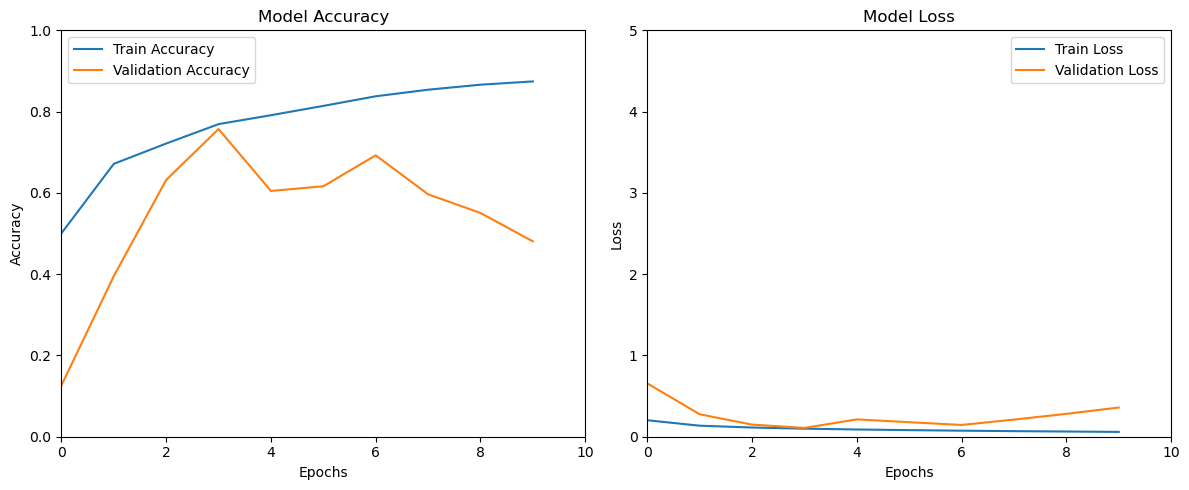

In [88]:
best_model = models.load_model("models/best_model.keras")

best_model_history = best_model.fit(
    X_train_resampled, y_train_resampled_one_hot,
    validation_data=(X_val_unbalanced, y_val_one_hot),
    epochs=10,
    batch_size=32,
)

plot_training_history(best_model_history)

In [35]:
# Running it over 4 epochs to retain best performance
best_model_history = best_model.fit(
    X_train_resampled, y_train_resampled_one_hot,
    validation_data=(X_val_unbalanced, y_val_one_hot),
    epochs=4,
    batch_size=32,
)

Epoch 1/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.8163 - loss: 0.0797 - val_accuracy: 0.6298 - val_loss: 0.1887
Epoch 2/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 872ms/step - accuracy: 0.8360 - loss: 0.0723 - val_accuracy: 0.7185 - val_loss: 0.1531
Epoch 3/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 152s 923ms/step - accuracy: 0.8514 - loss: 0.0662 - val_accuracy: 0.7696 - val_loss: 0.1015
Epoch 4/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 151s 912ms/step - accuracy: 0.8645 - loss: 0.0617 - val_accuracy: 0.7466 - val_loss: 0.1275


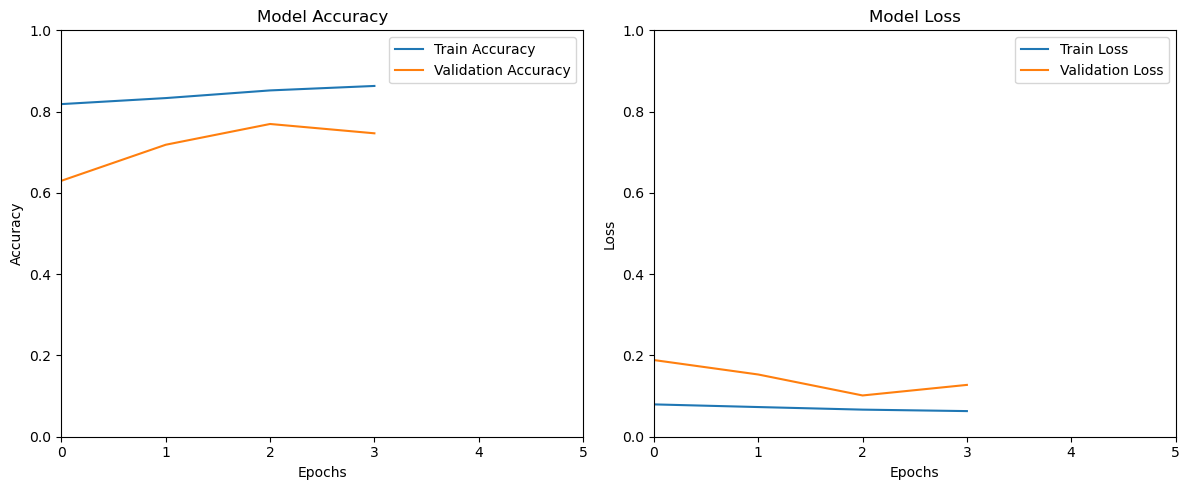

In [36]:
plot_training_history(best_model_history, acc_lims=(5, 1), loss_lims=(5, 1))

30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 246ms/step


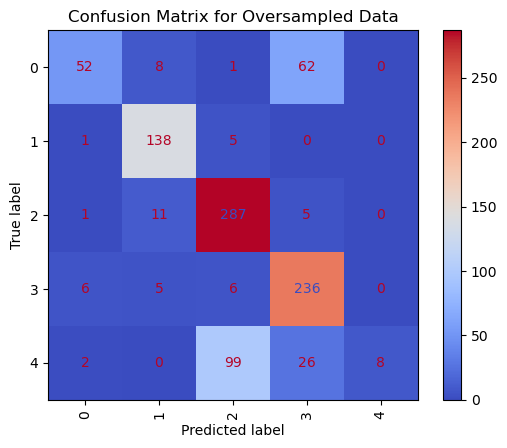

Accuracy: 0.7518248175182481


In [37]:
y_pred_probs = best_model.predict(X_test_unbalanced)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_test_classes = np.argmax(y_test_one_hot, axis=1)

accuracy = accuracy_score(y_test_classes, y_pred_classes)
matrix = confusion_matrix(y_test_classes, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(y_test_classes))
cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix for Oversampled Data")
plt.show()

print(f"Accuracy: {accuracy}")

In [16]:
best_hps.values

{'dropout_rate': 0.075,
 'l2_factor': 0.0001,
 'learning_rate': 0.0005,
 'tuner/epochs': 10,
 'tuner/initial_epoch': 4,
 'tuner/bracket': 2,
 'tuner/round': 2,
 'tuner/trial_id': '0012'}

# Crossvalidation

Crossvalidating the tuned model. Introducing evaluation metrics such as F1 score, precision, recall, and accuracy.

In [120]:
folds = 3
kf = KFold(n_splits=folds, shuffle=True, random_state=42)
fold_results = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1_score": [],
}

for train_index, val_index in kf.split(X_train_resampled):
    X_fold_train, X_fold_val = X_train_resampled[train_index], X_train_resampled[val_index]
    y_fold_train, y_fold_val = y_train_resampled_one_hot[train_index], y_train_resampled_one_hot[val_index]

    model = models.load_model("models/best_model.keras")

    history = model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=5,
        batch_size=32
    )

    # Predict on the validation fold
    y_pred_probs = model.predict(X_fold_val)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    y_true_classes = np.argmax(y_fold_val, axis=1)

    # evaluation metrics
    precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
    recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
    f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')
    accuracy = accuracy_score(y_true_classes, y_pred_classes)

    fold_results['accuracy'].append(accuracy)
    fold_results['precision'].append(precision)
    fold_results['recall'].append(recall)
    fold_results['f1_score'].append(f1)


print("\nCross-Validation Results:")
for metric, values in fold_results.items():
    print(f"{metric}: Mean = {np.mean(values):.4f}, Std = {np.std(values):.4f}")


/opt/anaconda3/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 50 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.3657 - loss: 0.2545 - val_accuracy: 0.1998 - val_loss: 0.5363
Epoch 2/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 104s 932ms/step - accuracy: 0.6287 - loss: 0.1597 - val_accuracy: 0.2898 - val_loss: 0.4564
Epoch 3/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 97s 866ms/step - accuracy: 0.6694 - loss: 0.1370 - val_accuracy: 0.2794 - val_loss: 0.3370
Epoch 4/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 96s 882ms/step - accuracy: 0.6959 - loss: 0.1238 - val_accuracy: 0.4180 - val_loss: 0.2581
Epoch 5/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 90s 810ms/step - accuracy: 0.7380 - loss: 0.1111 - val_accuracy: 0.4042 - val_loss: 0.2906
55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step


/opt/anaconda3/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 50 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.3793 - loss: 0.2628 - val_accuracy: 0.2754 - val_loss: 0.4856
Epoch 2/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 100s 883ms/step - accuracy: 0.6083 - loss: 0.1583 - val_accuracy: 0.3730 - val_loss: 0.3552
Epoch 3/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 130s 801ms/step - accuracy: 0.6692 - loss: 0.1307 - val_accuracy: 0.3412 - val_loss: 0.3105
Epoch 4/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 87s 797ms/step - accuracy: 0.7134 - loss: 0.1144 - val_accuracy: 0.4925 - val_loss: 0.1944
Epoch 5/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 103s 937ms/step - accuracy: 0.7477 - loss: 0.1058 - val_accuracy: 0.7050 - val_loss: 0.1208
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step


/opt/anaconda3/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 50 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 161s 951ms/step - accuracy: 0.3563 - loss: 0.2655 - val_accuracy: 0.3449 - val_loss: 0.4310
Epoch 2/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 100s 891ms/step - accuracy: 0.6309 - loss: 0.1625 - val_accuracy: 0.4541 - val_loss: 0.2392
Epoch 3/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 86s 776ms/step - accuracy: 0.6780 - loss: 0.1360 - val_accuracy: 0.5199 - val_loss: 0.2032
Epoch 4/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 90s 825ms/step - accuracy: 0.7277 - loss: 0.1174 - val_accuracy: 0.4812 - val_loss: 0.2218
Epoch 5/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 92s 843ms/step - accuracy: 0.7504 - loss: 0.1055 - val_accuracy: 0.5864 - val_loss: 0.2116
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step


/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Cross-Validation Results:
accuracy: Mean = 0.5652, Std = 0.1237
precision: Mean = 0.6165, Std = 0.1041
recall: Mean = 0.5652, Std = 0.1237
f1_score: Mean = 0.5335, Std = 0.1304


In [121]:
for metric, scores in fold_results.items():
    print(f"Average {metric}: {np.mean(scores)}")

Average accuracy: 0.5651628880412387
Average precision: 0.6164885027109724
Average recall: 0.5651628880412387
Average f1_score: 0.533485749558245


# Explainable AI - Explaining how to model works

GradCAM

In [23]:
best_model = models.load_model("models/best_model.keras")

/opt/anaconda3/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 50 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [15]:
def grad_cam(model, img, class_idx, layer_name='conv2d'):
    """
    Generates a Grad-CAM heatmap for a given image and model.

    Args:
        model (tf.keras.Model): Model to use for Grad-CAM.
        img (np.ndarray): Image to generate heatmap for.
        class_idx (int): Index of the class to generate
        layer_name (str): Name of the layer to use for Grad-CAM.

    Returns:
        np.ndarray: Heatmap for the image.
    """

    grad_model = models.Model(
        inputs=[model.inputs], 
        outputs=[
            model.get_layer(layer_name).output, 
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(np.expand_dims(img, axis=0))
        loss = predictions[:, class_idx]
    
    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]

    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_output), axis=-1).numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (img.shape[0], img.shape[1])).numpy()
    heatmap_resized = np.squeeze(heatmap_resized)

    return heatmap_resized

In [42]:
# Analysing correct and incorrect classifications
y_test_one_hot = to_categorical(y_test_unbalanced, num_classes=5)
preds = best_model.predict(X_test_unbalanced)
y_pred_classes = np.argmax(preds, axis=1)
y_test_classes = np.argmax(y_test_one_hot, axis=1)

correct_indicies = [
    i for i in range(len(y_test_classes)) if y_pred_classes[i] == y_test_classes[i]
    ]

misclassified_indicies = [
    i for i in range(len(y_test_classes)) if y_pred_classes[i] != y_test_classes[i]
]

misclassified_by_class = defaultdict(list)
for i in misclassified_indicies:
    misclassified_by_class[y_test_classes[i]].append(i)

correct_samples = random.sample(correct_indicies, 5)
# ensureing miscclassified samples are from atleast 2 different classes

misclassified_samples = []
for predicted_class, indicies in misclassified_by_class.items():
    if len(misclassified_samples) >= 5:
        break

    misclassified_samples.extend(random.sample(indicies, min(3, len(indicies))))

misclassified_samples = misclassified_samples[:5]

30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step


In [43]:
print(f"accuracy: {accuracy_score(y_test_classes, y_pred_classes)}")
Counter(y_pred_classes)

accuracy: 0.7518248175182481


Counter({2: 398, 3: 329, 1: 162, 0: 62, 4: 8})

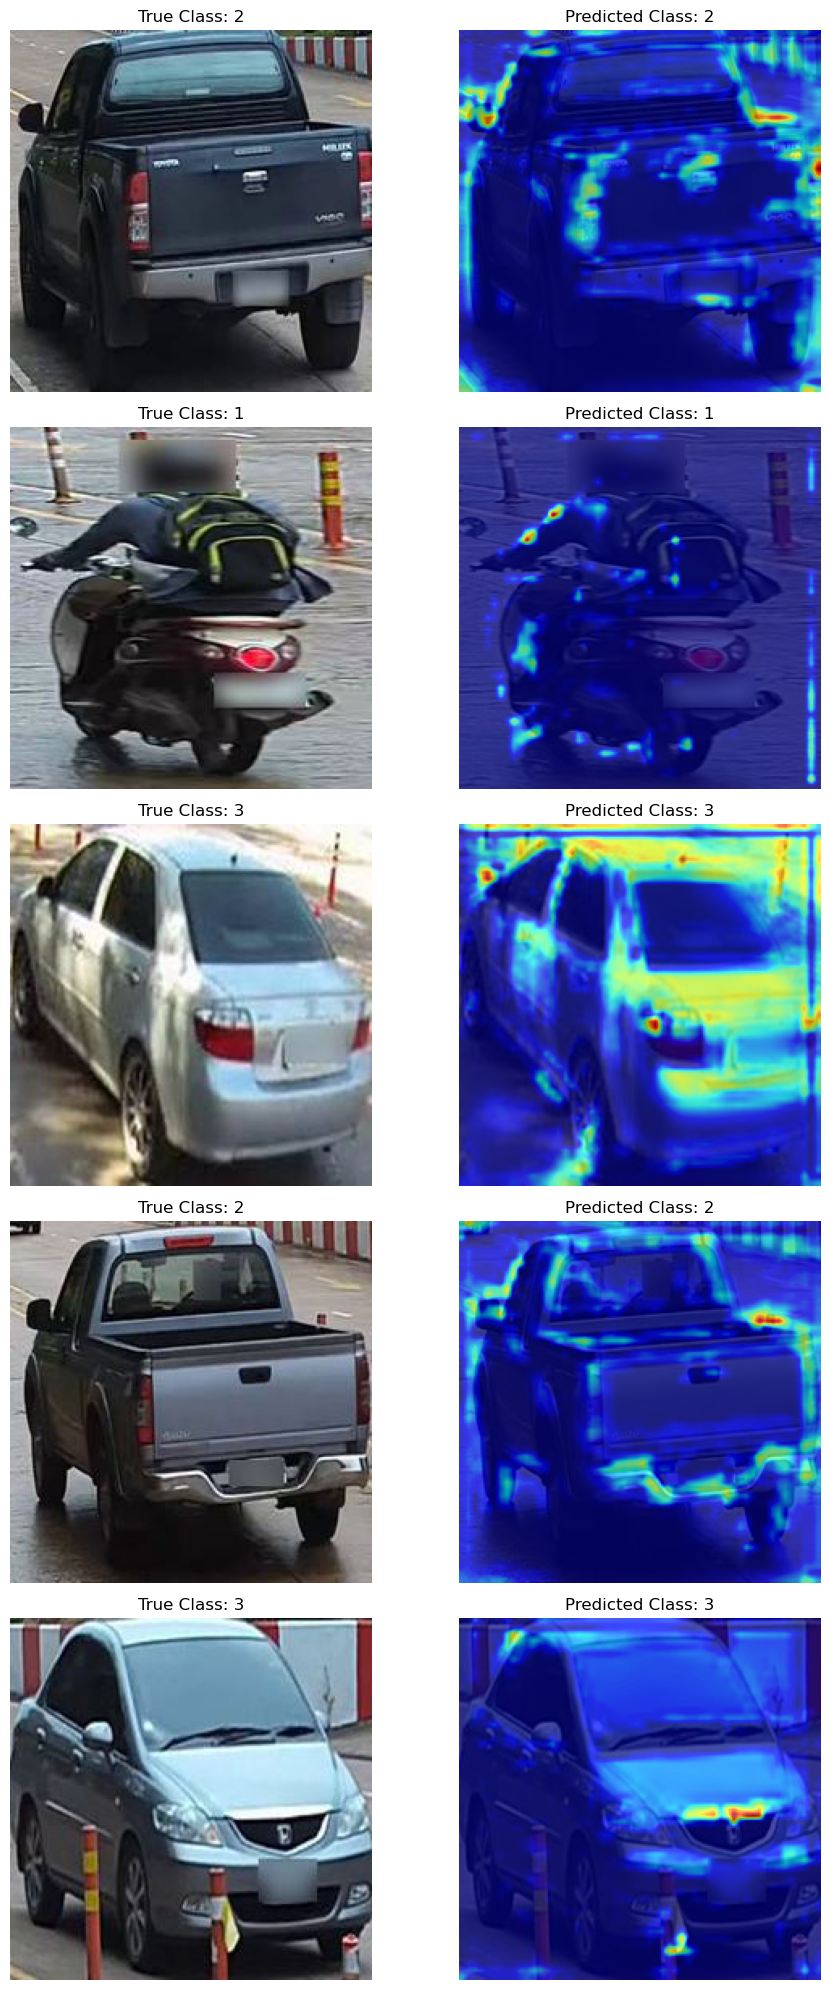

In [45]:
fig, axes = plt.subplots(5,2, figsize=(10, 20))

for i, idx in enumerate(correct_samples):
    row = i
    img = X_test_unbalanced[idx]
    true_class = y_test_classes[idx]
    predicted_class = y_pred_classes[idx]

    axes[row, 0].imshow(img)
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f"True Class: {true_class}")

    heatmap = grad_cam(best_model, img, predicted_class, layer_name='conv2d_7')
    axes[row, 1].imshow(img)
    axes[row, 1].imshow(heatmap, cmap='jet', alpha=0.7)
    axes[row, 1].axis('off')
    axes[row, 1].set_title(f"Predicted Class: {predicted_class}")

plt.tight_layout()
plt.show()

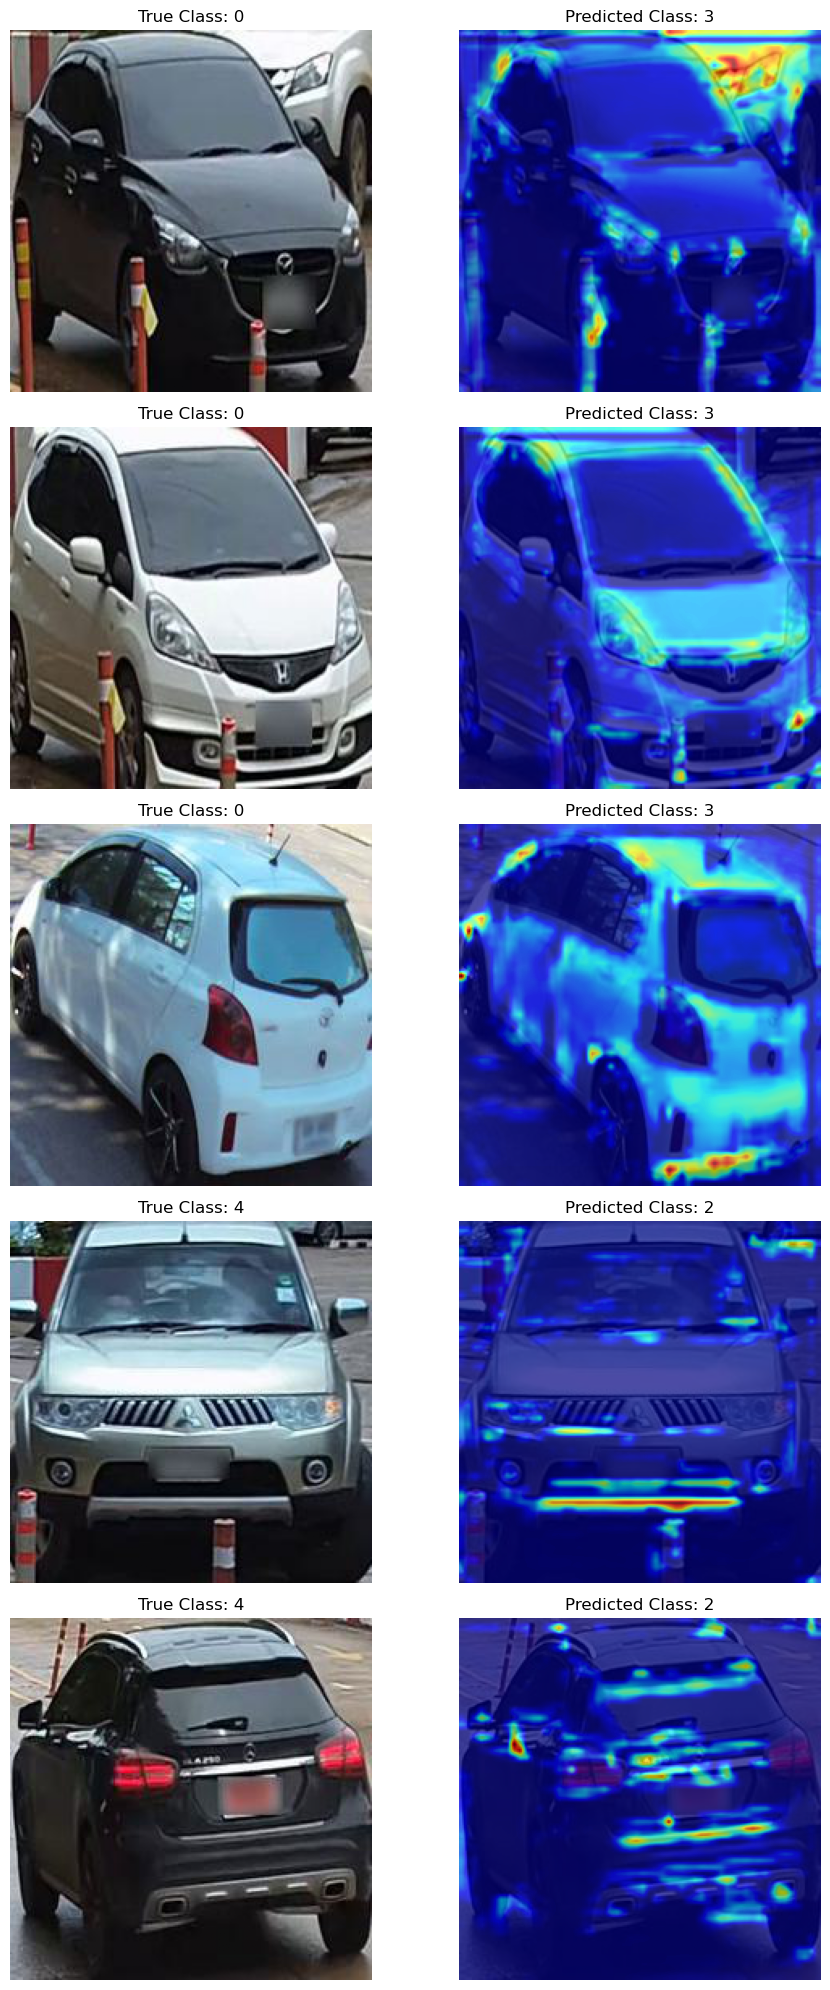

In [47]:
fig, axes = plt.subplots(5,2, figsize=(10, 20))

for i, idx in enumerate(misclassified_samples):
    row = i
    img = X_test_unbalanced[idx]
    true_class = y_test_classes[idx]
    predicted_class = y_pred_classes[idx]

    axes[row, 0].imshow(img)
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f"True Class: {true_class}")

    heatmap = grad_cam(best_model, img, predicted_class, layer_name='conv2d_7')
    axes[row, 1].imshow(img)
    axes[row, 1].imshow(heatmap, cmap='jet', alpha=0.7)
    axes[row, 1].axis('off')
    axes[row, 1].set_title(f"Predicted Class: {predicted_class}")

plt.tight_layout()
plt.show()

SHAP

In [48]:
selected_indices = correct_samples + misclassified_samples
selected_images = X_test_unbalanced[selected_indices]

In [49]:
explainer = shap.DeepExplainer(best_model, X_train_unbalanced[:50])
shap_values = explainer.shap_values(selected_images)

/opt/anaconda3/lib/python3.11/site-packages/shap/explainers/_deep/deep_tf.py:99: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn("Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.")
/opt/anaconda3/lib/python3.11/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


/opt/anaconda3/lib/python3.11/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(100, 224, 224, 3))']
  warnings.warn(msg)
/opt/anaconda3/lib/python3.11/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(10, 224, 224, 3))']
  warnings.warn(msg)


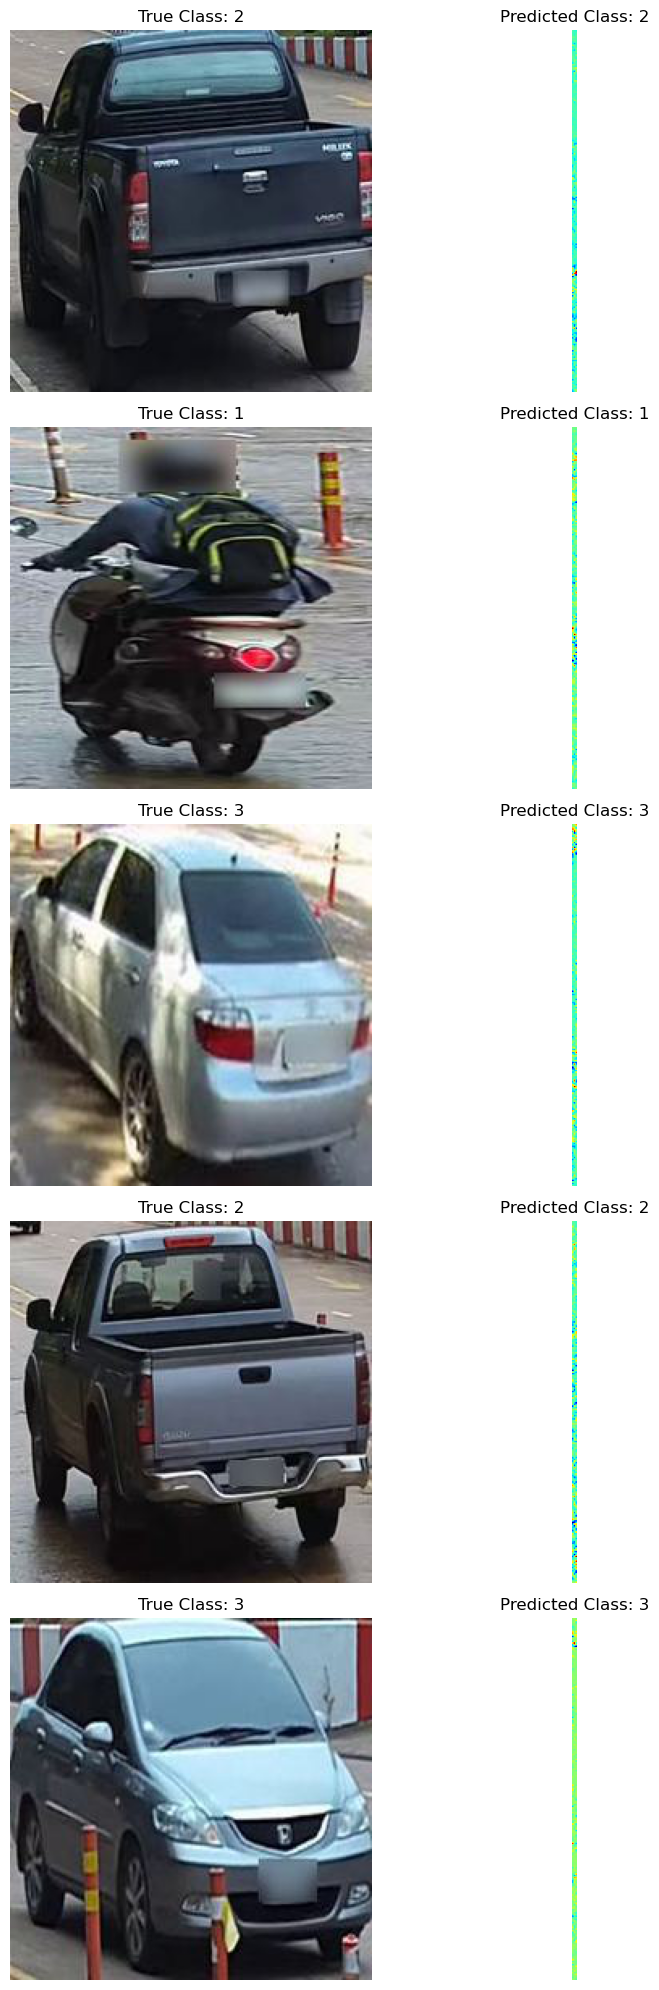

In [52]:
fig, axes = plt.subplots(5,2, figsize=(10, 20))

for i, idx in enumerate(correct_samples):
    row = i
    img = X_test_unbalanced[idx]
    true_class = y_test_classes[idx]
    predicted_class = y_pred_classes[idx]

    axes[row, 0].imshow(img)
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f"True Class: {true_class}")

    shap_value = shap_values[predicted_class][i]
    shap_value_resized = np.mean(shap_value, axis=-1)
    axes[row, 1].imshow(shap_value_resized, cmap="jet")
    axes[row, 1].axis('off')
    axes[row, 1].set_title(f"Predicted Class: {predicted_class}")

plt.tight_layout()
plt.show()

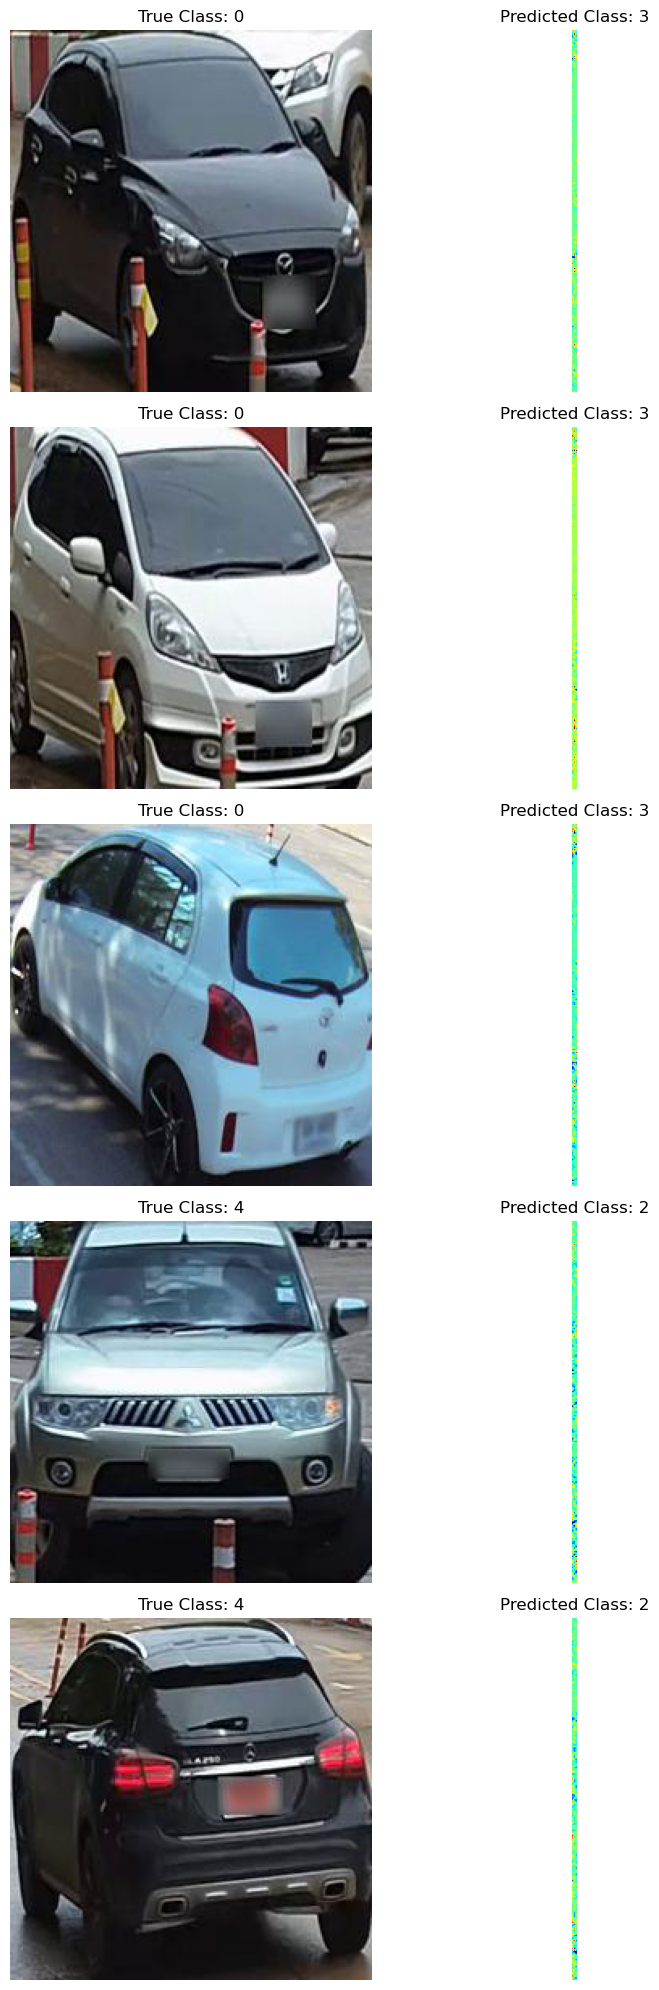

In [57]:
fig, axes = plt.subplots(5,2, figsize=(10, 20))

for i, idx in enumerate(misclassified_samples):
    row = i
    img = X_test_unbalanced[idx]
    true_class = y_test_classes[idx]
    predicted_class = y_pred_classes[idx]

    axes[row, 0].imshow(img)
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f"True Class: {true_class}")

    shap_value = shap_values[predicted_class][i]
    shap_value_resized = np.mean(shap_value, axis=-1)
    axes[row, 1].imshow(shap_value_resized, cmap="jet")
    axes[row, 1].axis('off')
    axes[row, 1].set_title(f"Predicted Class: {predicted_class}")

plt.tight_layout()
plt.show()

# Further Experimentation

## Increased Model Complexity

Increasing complexity through the DenseNet-169 architecture.

In [122]:
def complex_model(
        input_shape=(224, 224, 3), 
        num_classes=5, 
        dropout_rate=0.2,
        growth_rate=32
):
    inputs = layers.Input(shape=input_shape)

    # initial convolution with many more kernerls
    x = layers.Conv2D(64, (7, 7), strides=2, padding="same", activation="relu", kernel_initializer=initializers.HeNormal(seed=42))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding="same")(x)

    # 4 dense blocks with many more kernels
    for _ in range(4):
        y = layers.Conv2D(4 * growth_rate, (1, 1), kernel_initializer=initializers.HeNormal(seed=42))(x)
        y = layers.BatchNormalization()(y)
        y = layers.ReLU()(y)
        y = layers.Conv2D(growth_rate, (3, 3), padding="same", kernel_initializer=initializers.HeNormal(seed=42))(y)
        x = layers.Concatenate()([x, y])

    x = layers.Conv2D(x.shape[-1] // 2, (1, 1), activation="relu", kernel_initializer=initializers.HeNormal(seed=42))(x)
    x = layers.AveragePooling2D((2, 2), strides=2)(x)

    # 8 more dense blocks
    for _ in range(8):
        y = layers.Conv2D(4 * growth_rate, (1, 1), kernel_initializer=initializers.HeNormal(seed=42))(x)
        y = layers.BatchNormalization()(y)
        y = layers.ReLU()(y)
        y = layers.Conv2D(growth_rate, (3, 3), padding="same", kernel_initializer=initializers.HeNormal(seed=42))(y)
        x = layers.Concatenate()([x, y])

    x = layers.Conv2D(x.shape[-1] // 2, (1, 1), activation="relu", kernel_initializer=initializers.HeNormal(seed=42))(x)
    x = layers.AveragePooling2D((2, 2), strides=2)(x)

    # 6 more dense blocks
    for _ in range(6):
        y = layers.Conv2D(4 * growth_rate, (1, 1), kernel_initializer=initializers.HeNormal(seed=42))(x)
        y = layers.BatchNormalization()(y)
        y = layers.ReLU()(y)
        y = layers.Conv2D(growth_rate, (3, 3), padding="same", kernel_initializer=initializers.HeNormal(seed=42))(y)
        x = layers.Concatenate()([x, y])

    # output with a single dropout layer
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax", kernel_initializer=initializers.HeNormal(seed=42))(x)

    model = models.Model(inputs, outputs)
    return model

       


In [8]:
model_eleven = complex_model()

optimiser = Adam(learning_rate=0.00003)
model_eleven.compile(
    optimizer=optimiser,
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']    
)

model_eleven.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │      8,320 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,896 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 56, 56,    │          0 │ max_pooling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     12,416 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     36,896 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 56, 56,    │          0 │ concatenate[0][0… │
│ (Concatenate)       │ 128)              │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 56, 56,    │     16,512 │ concatenate_1[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat

 Total params: 1,236,293 (4.72 MB)

 Trainable params: 1,230,821 (4.70 MB)

 Non-trainable params: 5,472 (21.38 KB)

/opt/anaconda3/lib/python3.11/site-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


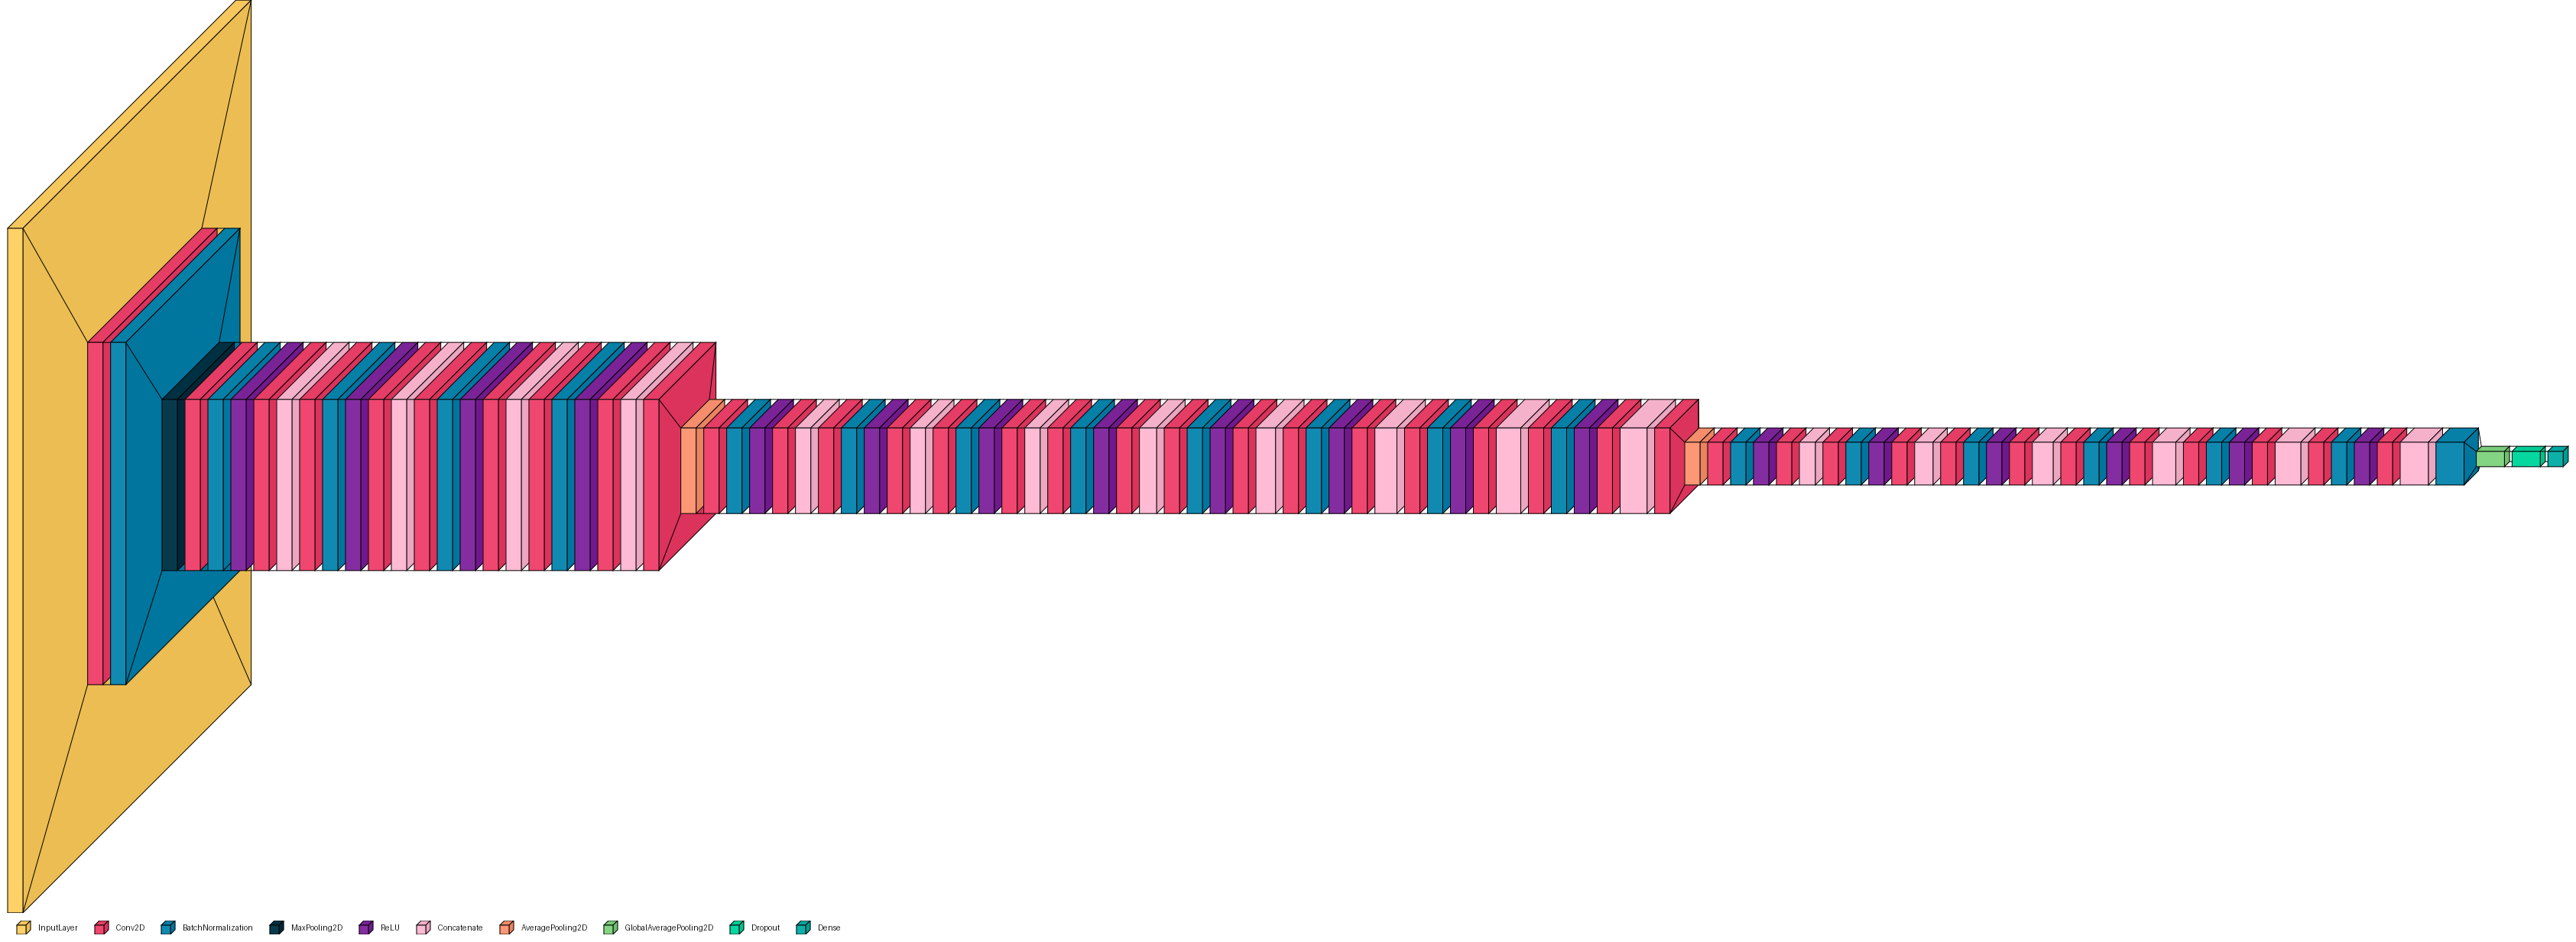

In [9]:
visualkeras.layered_view(
    model_eleven,
    to_file='model_eleven_visual.png',
    legend=True,
)


In [ ]:
history_complex = model_eleven.fit(
    X_train, y_train,
    validation_data =(X_val, y_val),
    epochs=10,
    batch_size=32
)

model_eleven.save('models/complex_model.keras')

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 597s 8s/step - accuracy: 0.3921 - loss: 1.4194 - val_accuracy: 0.1667 - val_loss: 1.9070
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 525s 7s/step - accuracy: 0.6058 - loss: 1.0192 - val_accuracy: 0.3900 - val_loss: 2.1547
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 521s 7s/step - accuracy: 0.7095 - loss: 0.8279 - val_accuracy: 0.4250 - val_loss: 2.3684
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 532s 7s/step - accuracy: 0.7709 - loss: 0.6853 - val_accuracy: 0.4183 - val_loss: 2.2809
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 525s 7s/step - accuracy: 0.8126 - loss: 0.5745 - val_accuracy: 0.4500 - val_loss: 1.7886
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 510s 7s/step - accuracy: 0.8524 - loss: 0.4736 - val_accuracy: 0.6500 - val_loss: 1.0697
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 474s 6s/step - accuracy: 0.8940 - loss: 0.3778 - val_accuracy: 0.7567 - val_loss: 0.6654
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 486s 6s/step - accuracy: 0.9168 - loss: 0.3039 - val_accuracy: 0.7833 - v

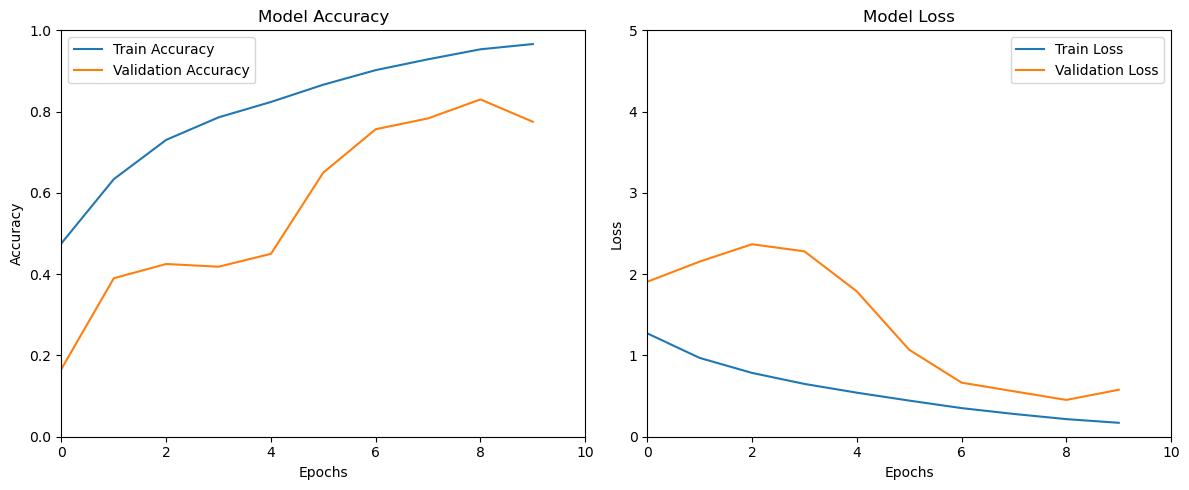

In [11]:
plot_training_history(history_complex)

In [59]:
model_eleven = models.load_model('models/complex_model.keras')

19/19 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step


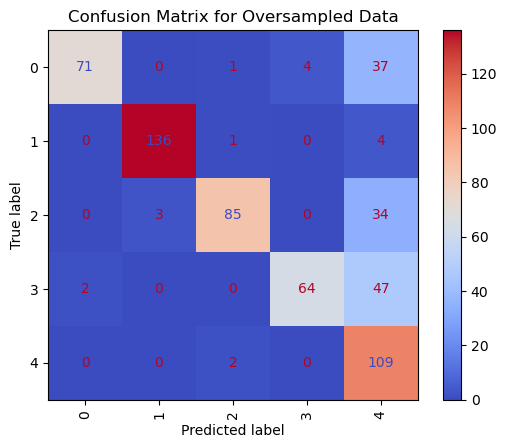

Accuracy: 0.775


In [67]:
y_pred_probs = model_eleven.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_test_classes = np.argmax(y_test_one_hot, axis=1)

accuracy = accuracy_score(y_test_classes, y_pred_classes)
matrix = confusion_matrix(y_test_classes, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(y_test_classes))
cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix for Oversampled Data")
plt.show()

print(f"Accuracy: {accuracy}")

In [16]:
folds = 3
kf = KFold(n_splits=folds, shuffle=True, random_state=42)
fold_results = {
    "accuracy" : [],
    "precision": [],
    "recall": [],
    "f1_score": [],
}

for train_index, test_index, in kf.split(X_train):
    X_fold_train, X_fold_val = X_train_unbalanced[train_index], X_train_unbalanced[test_index]
    y_fold_train, y_fold_val = y_train_unbalanced[train_index], y_train_unbalanced[test_index]

    model =  models.load_model("models/complex_model.keras")

    history = model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=10,
        batch_size=32
    )

    y_pred_probs = model.predict(X_fold_val)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    y_true_classes = y_fold_val

    precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
    recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
    f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')
    val_accuracy = history.history['val_accuracy'][-1]


    fold_results['accuracy'].append(val_accuracy)
    fold_results['precision'].append(precision)
    fold_results['recall'].append(recall)
    fold_results['f1_score'].append(f1)

    print(f"Fold Validation Accuracy: {val_accuracy}")

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 383s 7s/step - accuracy: 0.8867 - loss: 0.3381 - val_accuracy: 0.6212 - val_loss: 1.0744
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 365s 7s/step - accuracy: 0.9352 - loss: 0.2420 - val_accuracy: 0.6712 - val_loss: 0.8847
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 344s 7s/step - accuracy: 0.9634 - loss: 0.1817 - val_accuracy: 0.8388 - val_loss: 0.4522
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 409s 8s/step - accuracy: 0.9761 - loss: 0.1446 - val_accuracy: 0.8525 - val_loss: 0.4175
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 351s 7s/step - accuracy: 0.9795 - loss: 0.1240 - val_accuracy: 0.9237 - val_loss: 0.2385
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 372s 7s/step - accuracy: 0.9896 - loss: 0.0975 - val_accuracy: 0.9262 - val_loss: 0.2341
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 338s 7s/step - accuracy: 0.9901 - loss: 0.0804 - val_accuracy: 0.9375 - val_loss: 0.2034
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 342s 7s/step - accuracy: 0.9962 - loss: 0.0702 - val_accuracy: 0.9287 - v

In [17]:
print(f'Mean accuracy: ', np.mean(fold_results['accuracy']))
print(f'Mean precision: ', np.mean(fold_results['precision']))
print(f'Mean recall: ', np.mean(fold_results['recall']))
print(f'Mean F1 Score: ', np.mean(fold_results['f1_score']))

Mean accuracy:  0.9433333277702332
Mean precision:  0.9449595319475982
Mean recall:  0.9433333333333334
Mean F1 Score:  0.943029386759212
